# NutriNER Cross-Dataset Benchmark

Runs the five NER variants from `ner_variants_reduced.ipynb` across all five question datasets
and produces a full set of quantitative and qualitative outputs for each.

**Models:** en_core_sci_lg · gliner_custom_flat · gliner_custom_nested · gliner2_custom · scifoodner_cafeteria  
**Datasets:** multihop_qa · textbook_lyssari · single_abstract · mmlu · hai_coaching · ngqa  
**Outputs per dataset:** metrics table · cumulative plot · distribution plot · Jaccard heatmap · asymmetric coverage heatmap · SapBERT semantic coverage heatmap · qualitative side-by-side  
**Cross-dataset:** avg-entities table + grouped bar chart

In [1]:
# ── Cell 1: Imports and GPU setup ────────────────────────────────────────────
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"   # pin to GPU 0

import sys, json, warnings
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F
from IPython.display import display

warnings.filterwarnings("ignore")

if torch.cuda.is_available():
    torch.cuda.init()
    torch.cuda.set_device(0)
torch.backends.cudnn.enabled = False

from gliner import GLiNER

# ── Paths ────────────────────────────────────────────────────────────────────
QUESTIONS_DIR = Path("/mnt/data/vpitsilou/wisefood/new_experiments/questions")
OUT_BASE      = Path("/mnt/data/makis/wisefood/experiments/tests/ner_results/cross_dataset")
CACHE_DIR     = OUT_BASE / "cache"
OUT_BASE.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(exist_ok=True)

SCIFOODNER_MODEL_DIR   = "/mnt/data/vpitsilou/scifoodner/cafeteria/best"
SCIFOODNER_LABELS_PATH = "/mnt/data/vpitsilou/wisefood/experiments/code/LinearRAG/scifoodner/cafeteria.tsv"
GLINER_MODEL           = "Ihor/gliner-biomed-large-v1.0"
G2_MODEL               = "fastino/gliner2-large-v1"
SAPBERT_MODEL          = "cambridgeltl/SapBERT-from-PubMedBERT-fulltext"

GLINER_THRESHOLD  = 0.35
GLINER_MAX_LENGTH = 512
SEM_THRESHOLD     = 0.85

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print({"device": str(device), "cudnn_enabled": torch.backends.cudnn.enabled})

2026-06-12 13:26:08.850853188 [W:onnxruntime:Default, device_discovery.cc:283 GetGpuDevices] Failed to detect devices under "/sys/class/drm/card0": device_discovery.cc:93 ReadFileContents Failed to open file: "/sys/class/drm/card0/device/vendor"


{'device': 'cuda:0', 'cudnn_enabled': False}


In [2]:
# ── Cell 2: Label sets ───────────────────────────────────────────────────────
GLINER_CUSTOM_LABELS = [
    "food", "food additive", "dietary pattern", "dietary supplement",
    "nutrient", "vitamin", "mineral", "amino acid", "lipid", "chemical",
    "drug", "biomarker", "enzyme", "hormone", "gene", "genotype", "microbe",
    "disease", "symptom", "organ or tissue", "physiological process",
    "population", "life stage", "exercise", "measurement", "time expression", "country"
]

GLINER2_CUSTOM_LABELS = {
    "food":
        "Specific food items, ingredients, or beverages mentioned by name in scientific nutrition text "
        "(e.g. olive oil, red meat, green tea, whole grains, salmon, blueberries)",
    "food additive":
        "Substances intentionally added to food for preservation, flavouring, colouring, or texturising "
        "(e.g. sodium benzoate, aspartame, monosodium glutamate, lecithin, carrageenan)",
    "dietary pattern":
        "Structured overall eating patterns or dietary regimens studied as an intervention or exposure "
        "(e.g. Mediterranean diet, Western diet, DASH diet, plant-based diet, ketogenic diet, veganism)",
    "dietary supplement":
        "Nutritional supplements or nutraceuticals taken in addition to normal diet "
        "(e.g. fish oil capsules, multivitamins, probiotic supplements, omega-3 supplements, protein powder)",
    "nutrient":
        "General nutritional components not classified as a specific vitamin or mineral "
        "(e.g. dietary fibre, total protein, carbohydrate, polyphenol, antioxidant, omega-3 fatty acid, flavonoid)",
    "vitamin":
        "Specific vitamins identified by letter, number, or full chemical name "
        "(e.g. vitamin C, vitamin D3, retinol, alpha-tocopherol, folate, riboflavin, thiamine, niacin)",
    "mineral":
        "Specific dietary minerals or trace elements "
        "(e.g. calcium, magnesium, iron, zinc, selenium, potassium, sodium, phosphorus, iodine)",
    "amino acid":
        "Specific amino acids as building blocks of proteins or metabolic intermediates "
        "(e.g. leucine, tryptophan, glutamine, methionine, arginine, branched-chain amino acids)",
    "lipid":
        "Specific fats, fatty acids, cholesterol fractions, or lipid molecules "
        "(e.g. LDL cholesterol, triglycerides, arachidonic acid, DHA, EPA, saturated fatty acid)",
    "chemical":
        "Chemical compounds, molecules, or substances relevant to nutrition or biology "
        "that are not nutrients or drugs (e.g. resveratrol, curcumin, quercetin, ethanol, phytosterol)",
    "drug":
        "Pharmaceutical drugs, medications, or clinical interventions "
        "(e.g. metformin, statins, aspirin, insulin, orlistat)",
    "biomarker":
        "Measurable biological markers in blood, urine, or tissue used to assess metabolic or health status "
        "(e.g. HbA1c, C-reactive protein, LDL, BMI, fasting glucose, homocysteine, IL-6)",
    "enzyme":
        "Specific biological enzymes involved in metabolism, digestion, or biochemical pathways "
        "(e.g. lipase, amylase, COX-2, superoxide dismutase, glutathione peroxidase)",
    "hormone":
        "Hormones involved in metabolism, appetite regulation, or body homeostasis "
        "(e.g. insulin, leptin, ghrelin, cortisol, adiponectin, thyroid hormone)",
    "gene":
        "Named genes or gene symbols relevant to nutrition or metabolism research "
        "(e.g. APOE, FTO, PPARG, TCF7L2, MTHFR)",
    "genotype":
        "Genetic variants, single nucleotide polymorphisms, or genotypes "
        "(e.g. APOE epsilon4 allele, rs9939609, MTHFR C677T, heterozygous carriers)",
    "microbe":
        "Bacteria, viruses, fungi, or other microorganisms relevant to gut health or disease "
        "(e.g. Lactobacillus, Bifidobacterium, Helicobacter pylori, gut microbiota)",
    "disease":
        "Diagnosed medical conditions, disorders, or pathological conditions "
        "(e.g. type 2 diabetes, cardiovascular disease, obesity, metabolic syndrome, colorectal cancer)",
    "symptom":
        "Clinical symptoms, signs of disease, or physiological abnormalities reported in patients "
        "(e.g. hypertension, hyperglycaemia, systemic inflammation, fatigue, insulin resistance)",
    "organ or tissue":
        "Body organs, tissues, or anatomical structures "
        "(e.g. liver, skeletal muscle, adipose tissue, gut, colon, pancreas, small intestine)",
    "physiological process":
        "Biological or physiological processes and mechanisms in the body "
        "(e.g. oxidative stress, lipid oxidation, inflammation, gut microbiota composition, satiety signalling)",
    "population":
        "Defined human study groups or cohorts characterised by demographics, health status, or geography "
        "(e.g. postmenopausal women, elderly adults over 65, obese children, type 2 diabetic patients)",
    "life stage":
        "Specific stages of human life used as inclusion criteria or study context "
        "(e.g. infancy, childhood, adolescence, pregnancy, lactation, menopause, old age)",
    "exercise":
        "Physical exercise interventions, physical activity levels, or sport modalities "
        "(e.g. aerobic exercise, resistance training, sedentary behaviour, walking, HIIT)",
    "measurement":
        "Quantitative measurements, dosages, amounts, or clinical indices with units "
        "(e.g. 500 mg/day, 2 g/kg body weight, 30% energy from fat, 95th percentile BMI)",
    "time expression":
        "Time periods, durations, follow-up intervals, or temporal references in study design "
        "(e.g. 12 weeks, 5-year follow-up, baseline, 6 months post-intervention, 24-hour recall)",
    "country":
            "Countries, sovereign states, territories, or national geographic entities "
            "(e.g. Greece, United States, China, Japan, United Kingdom, South Korea).", 
}
print(f"Labels: {len(GLINER_CUSTOM_LABELS)} list / {len(GLINER2_CUSTOM_LABELS)} dict")

Labels: 27 list / 27 dict


In [3]:
# ── Cell 3: NER runner functions ─────────────────────────────────────────────

def scispacy_rows(df, run_name="en_core_sci_lg"):
    """Run en_core_sci_lg NER entity extraction (doc.ents)."""
    import spacy
    nlp = spacy.load("en_core_sci_lg")
    rows = []
    for qid, text in zip(df["question_id"], df["question"]):
        doc = nlp(str(text))
        seen = set()
        for ent in doc.ents:
            et = ent.text.strip()
            if len(et) < 2 or et.lower() in seen:
                continue
            seen.add(et.lower())
            rows.append({
                "question_id": qid, "model": run_name,
                "entity_text": et, "entity_label": ent.label_,
                "start": ent.start_char, "end": ent.end_char,
                "label_scores": {ent.label_: 1.0},
            })
    del nlp
    return pd.DataFrame(rows)


def gliner_rows(df, flat_ner=True, run_name=None, batch_size=32):
    run_name = run_name or ("gliner_custom_flat" if flat_ner else "gliner_custom_nested")
    model = GLiNER.from_pretrained(GLINER_MODEL, max_length=GLINER_MAX_LENGTH)
    model = model.to(device)
    tok = getattr(model.data_processor, "transformer_tokenizer", None)
    if tok:
        tok.model_max_length = GLINER_MAX_LENGTH
    batch_predictions = model.inference(
        df["question"].tolist(), GLINER_CUSTOM_LABELS,
        threshold=GLINER_THRESHOLD, multi_label=True,
        batch_size=batch_size, flat_ner=flat_ner,
    )
    rows = []
    for qid, preds in zip(df["question_id"], batch_predictions):
        grouped = {}
        for ent in preds:
            key = (ent.get("start"), ent.get("end"), ent.get("text", ""))
            item = grouped.setdefault(key, {
                "question_id": qid, "model": run_name,
                "entity_text": ent.get("text", ""), "entity_label": [],
                "start": ent.get("start"), "end": ent.get("end"), "label_scores": {},
            })
            lbl, score = ent.get("label"), ent.get("score")
            if lbl:
                item["label_scores"][lbl] = max(item["label_scores"].get(lbl, float("-inf")), score)
        for item in grouped.values():
            lbls = sorted(item["label_scores"], key=lambda l: (-item["label_scores"][l], l))
            item["entity_label"] = lbls[0] if len(lbls) == 1 else lbls
            rows.append(item)
    del model; torch.cuda.empty_cache()
    return pd.DataFrame(rows)


def gliner2_rows(df, run_name="gliner2_custom", batch_size=16):
    from gliner2 import GLiNER2
    map_loc = "cuda" if torch.cuda.is_available() else "cpu"
    model = GLiNER2.from_pretrained(G2_MODEL, map_location=map_loc, quantize=(map_loc == "cuda"))
    texts = df["question"].tolist()
    batch_results = model.batch_extract_entities(
        texts, GLINER2_CUSTOM_LABELS,
        batch_size=batch_size, threshold=GLINER_THRESHOLD,
        include_confidence=True, include_spans=True,
    )
    rows = []
    for qid, result in zip(df["question_id"], batch_results):
        grouped = {}
        for label, ents in result.get("entities", {}).items():
            for ent in ents:
                key = (ent.get("start"), ent.get("end"), ent.get("text", ""))
                item = grouped.setdefault(key, {
                    "question_id": qid, "model": run_name,
                    "entity_text": ent.get("text", ""), "entity_label": [],
                    "start": ent.get("start"), "end": ent.get("end"), "label_scores": {},
                })
                item["label_scores"][label] = max(
                    item["label_scores"].get(label, float("-inf")), ent.get("confidence", 1.0))
        for item in grouped.values():
            lbls = sorted(item["label_scores"], key=lambda l: (-item["label_scores"][l], l))
            item["entity_label"] = lbls[0] if len(lbls) == 1 else lbls
            rows.append(item)
    del model; torch.cuda.empty_cache()
    return pd.DataFrame(rows)


def _parse_scifoodner_preds(sentence_preds):
    entities, cur = [], []
    def flush():
        if cur: entities.append(" ".join(cur))
        cur.clear()
    for item in sentence_preds:
        token, tag = list(item.items())[0]
        prefix = tag.strip().split("-")[0] if "-" in tag.strip() else tag.strip()
        if prefix == "O": flush()
        elif prefix == "B": flush(); cur.append(token.strip())
        elif prefix == "I":
            cur.append(token.strip())
        else: flush()
    flush()
    return entities

def scifoodner_rows(df, run_name="scifoodner_cafeteria"):
    from simpletransformers.ner import NERModel, NERArgs
    ldf = pd.read_csv(SCIFOODNER_LABELS_PATH, sep="\t").dropna()
    ldf.columns = ["word", "tag"]
    labels = list(ldf["tag"].astype(str).drop_duplicates().values)
    args = NERArgs(); args.use_multiprocessing = False
    use_cuda = torch.cuda.is_available()
    model = NERModel("bert", SCIFOODNER_MODEL_DIR, args=args, labels=labels,
                     use_cuda=use_cuda, cuda_device=0 if use_cuda else -1)
    texts = df["question"].tolist()
    all_preds, _ = model.predict(texts)
    rows = []
    for qid, text, sent_preds in zip(df["question_id"], texts, all_preds):
        seen = set()
        for et in _parse_scifoodner_preds(sent_preds):
            et = et.strip()
            if not et or et.lower() in seen: continue
            seen.add(et.lower())
            idx = text.lower().find(et.lower())
            rows.append({"question_id": qid, "model": run_name,
                         "entity_text": et, "entity_label": "food",
                         "start": idx if idx >= 0 else None,
                         "end": idx + len(et) if idx >= 0 else None,
                         "label_scores": {"food": 1.0}})
    del model
    return pd.DataFrame(rows)

print("NER runners ready.")

NER runners ready.


In [4]:
# ── Ad-hoc: run GLiNER2 on a single text chunk ────────────────────────────────

from gliner2 import GLiNER2

_text = (
    "Defining what is meant by a sustainable diet is diffi.ligacult, and there is currently no consensus. The word sustainable itself is used in a number of ways, and there are generally accepted to be three broad &apos;pillars&apos; of sustainability; 1) economic, 2) social and 3) environmental. 30  All three are important when considering overall sustainability, but within the context of this reference guide and the BDA&apos;s Sustainable Diets policy, we have focused specifically on an environmentally sustainable diet. Fig 3.1: The three pillars of sustainability 30 Further complexity is added by the fact that environmental sustainability itself can have a range of meanings, and that there can often be diff.ligaering priorities land and water use, GHG emissions, biodiversity, etc. Sometimes one priority can contradict another. Despite this complexity it is important to have a clear direction of what is meant by the term sustainable diets, at least in relation to this reference guide. In this section we summarise the BDA recommendations and we consider definitions from key organisations and thinkers in the field, which taken together give a good indication of what is meant by an environmentally sustainable diet."
)

map_loc = "cuda" if torch.cuda.is_available() else "cpu"
_model = GLiNER2.from_pretrained(G2_MODEL, map_location=map_loc, quantize=(map_loc == "cuda"))

_results = _model.batch_extract_entities(
    [_text], GLINER2_CUSTOM_LABELS,
    batch_size=1, threshold=GLINER_THRESHOLD,
    include_confidence=True, include_spans=True,
)

print(f"Text:\n{_text}\n")
print("Entities found:")
for label, ents in sorted(_results[0].get("entities", {}).items()):
    for ent in ents:
        print(f"  [{label:45s}]  {ent['text']!r:40s}  (conf={ent['confidence']:.3f})")

del _model; torch.cuda.empty_cache()


🧠 Model Configuration
Encoder model      : microsoft/deberta-v3-large
Counting layer     : count_lstm
Token pooling      : first


Text:
Defining what is meant by a sustainable diet is diffi.ligacult, and there is currently no consensus. The word sustainable itself is used in a number of ways, and there are generally accepted to be three broad &apos;pillars&apos; of sustainability; 1) economic, 2) social and 3) environmental. 30  All three are important when considering overall sustainability, but within the context of this reference guide and the BDA&apos;s Sustainable Diets policy, we have focused specifically on an environmentally sustainable diet. Fig 3.1: The three pillars of sustainability 30 Further complexity is added by the fact that environmental sustainability itself can have a range of meanings, and that there can often be diff.ligaering priorities land and water use, GHG emissions, biodiversity, etc. Sometimes one priority can contradict another. Despite this complexity it is important to have a clear direction of what is meant by the term sustainable diets, at least in relation to this reference guid

In [5]:
# ── Cell 4: Dataset loaders ───────────────────────────────────────────────────

def _normalise(df, text_col="question", extra_cols=None):
    """Ensure columns question and question_id exist. Preserve extra_cols if given."""
    df = df.copy()
    if text_col != "question":
        df = df.rename(columns={text_col: "question"})
    df["question"] = df["question"].astype(str).str.strip()
    df = df.reset_index(drop=True)
    df.insert(0, "question_id", df.index + 1)
    cols = ["question_id", "question"] + (list(extra_cols) if extra_cols else [])
    return df[cols]

def load_multihop():
    df = pd.read_csv(QUESTIONS_DIR / "multihop_qa_2textbooks.csv", usecols=["question"])
    return _normalise(df)

def load_textbook_lyssari():
    df = pd.read_csv(QUESTIONS_DIR / "textbook-lyssari-qa.csv", usecols=["question"])
    return _normalise(df)

def load_single_abstract():
    df = pd.read_csv(QUESTIONS_DIR / "single_abstract_qa.csv", usecols=["question"])
    return _normalise(df)

def load_mmlu():
    # question column only — choices and answer are deliberately excluded
    df = pd.read_csv(QUESTIONS_DIR / "mmlu_full.csv", usecols=["question"])
    return _normalise(df)

def load_hai_coaching():
    # NER target is the 'struggle' column (user-generated informal text)
    df = pd.read_csv(QUESTIONS_DIR / "hai_coaching_struggle_suggestions.csv", usecols=["struggle"])
    return _normalise(df, text_col="struggle")

def load_ngqa():
    # NER target: person_profile + food_profile + question_easy (concatenated)
    # difficulty column preserved for stratified reporting
    NGQA_PATH = "/mnt/data/wisefood/foodscholar/NGQA/NGQA_binary_SAMPLE_270_qa.csv"
    df = pd.read_csv(NGQA_PATH)
    df["question"] = (
        df["person_profile"].fillna("").astype(str).str.strip() + "\n\n"
        + df["food_profile"].fillna("").astype(str).str.strip() + "\n\n"
        + df["question_easy"].fillna("").astype(str).str.strip()
    )
    return _normalise(df, extra_cols=["difficulty"])

DATASET_LOADERS = {
    "multihop_qa":        load_multihop,
    "textbook_lyssari":   load_textbook_lyssari,
    "single_abstract":    load_single_abstract,
    "mmlu":               load_mmlu,
    "hai_coaching":       load_hai_coaching,
    "ngqa":               load_ngqa,
}

print("Dataset loaders ready.")
for name, loader in DATASET_LOADERS.items():
    df = loader()
    extra = f"  | difficulties: {df['difficulty'].value_counts().to_dict()}" if "difficulty" in df.columns else ""
    print(f"  {name}: {len(df)} questions{extra}")


Dataset loaders ready.
  multihop_qa: 230 questions
  textbook_lyssari: 268 questions
  single_abstract: 100 questions
  mmlu: 344 questions
  hai_coaching: 2346 questions
  ngqa: 270 questions  | difficulties: {'easy': 90, 'medium': 90, 'hard': 90}


In [6]:
# ── Cell 5: Checkpoint helper + run_all_models_for_dataset ───────────────────

ALL_MODELS = [
    "en_core_sci_lg",
    "gliner_custom_flat",
    "gliner_custom_nested",
    "gliner2_custom",
    "scifoodner_cafeteria",
]

MODEL_COLORS = {
    "en_core_sci_lg":       "#1f77b4",
    "gliner_custom_flat":   "#ff7f0e",
    "gliner_custom_nested": "#2ca02c",
    "gliner2_custom":       "#9467bd",
    "scifoodner_cafeteria": "#d62728",
}

def run_or_load(cache_path, fn):
    """Load cached CSV if it exists; otherwise run fn(), save, and return."""
    p = Path(cache_path)
    if p.exists() and p.stat().st_size > 0:
        print(f"    [CACHE] {p.name}")
        return pd.read_csv(p)
    print(f"    [RUN]   {p.name}")
    result = fn()
    result.to_csv(p, index=False)
    return result


def _sapbert_to_cpu():
    """Offload SapBERT to CPU before GLiNER/SciFoodNER to free GPU memory."""
    if "_sap_mdl" in globals() and next(globals()["_sap_mdl"].parameters()).is_cuda:
        globals()["_sap_mdl"].cpu()
        torch.cuda.empty_cache()
        print("    [MEM] SapBERT offloaded to CPU")

def _sapbert_to_gpu():
    """Restore SapBERT to GPU after inference, before analysis."""
    if "_sap_mdl" in globals() and not next(globals()["_sap_mdl"].parameters()).is_cuda:
        globals()["_sap_mdl"].to(device)
        print("    [MEM] SapBERT restored to GPU")


def run_all_models_for_dataset(dataset_name, questions_df):
    """Run all 5 NER models on questions_df with per-model checkpointing."""
    pieces = []
    n = len(questions_df)
    # Smaller batch for large datasets to avoid OOM
    gliner_batch  = 16 if n > 500 else 32
    gliner2_batch = 8  if n > 500 else 16

    print(f"\n=== {dataset_name} ({n} questions | gliner_batch={gliner_batch}) ===")
    _sapbert_to_cpu()   # free GPU before loading inference models

    pieces.append(run_or_load(
        CACHE_DIR / f"{dataset_name}_en_core_sci_lg.csv",
        lambda: scispacy_rows(questions_df),
    ))

    pieces.append(run_or_load(
        CACHE_DIR / f"{dataset_name}_gliner_custom_flat.csv",
        lambda: gliner_rows(questions_df, flat_ner=True,
                            run_name="gliner_custom_flat", batch_size=gliner_batch),
    ))

    pieces.append(run_or_load(
        CACHE_DIR / f"{dataset_name}_gliner_custom_nested.csv",
        lambda: gliner_rows(questions_df, flat_ner=False,
                            run_name="gliner_custom_nested", batch_size=gliner_batch),
    ))

    pieces.append(run_or_load(
        CACHE_DIR / f"{dataset_name}_gliner2_custom.csv",
        lambda: gliner2_rows(questions_df, batch_size=gliner2_batch),
    ))

    pieces.append(run_or_load(
        CACHE_DIR / f"{dataset_name}_scifoodner_cafeteria.csv",
        lambda: scifoodner_rows(questions_df),
    ))

    _sapbert_to_gpu()   # restore for analysis

    all_ents = (
        pd.concat(pieces, ignore_index=True)
        .sort_values(["question_id","model","start","end","entity_text"], na_position="last")
        .reset_index(drop=True)
    )
    return all_ents

print("Checkpoint helpers ready.")

Checkpoint helpers ready.


In [7]:
# ── Cell 6: Analysis helpers ─────────────────────────────────────────────────

def question_entities_frame(question_df, entity_df):
    base = (question_df[["question_id","question"]].assign(key=1)
            .merge(pd.DataFrame({"model": ALL_MODELS, "key":1}), on="key").drop(columns="key"))
    grouped = (entity_df
        .sort_values(["question_id","model","start","end","entity_text"], na_position="last")
        .groupby(["question_id","model"], as_index=False)["entity_text"]
        .agg(lambda v: list(dict.fromkeys(x.lower().strip() for x in v if isinstance(x,str) and x.strip())))
        .rename(columns={"entity_text":"entities"}))
    merged = base.merge(grouped, on=["question_id","model"], how="left")
    merged["entities"] = merged["entities"].apply(lambda v: v if isinstance(v,list) else [])
    return merged


def metrics_table(all_qe):
    df = (all_qe.groupby("model", as_index=False)["entity_count"]
          .agg(zero_entity_questions=lambda v: int((v==0).sum()),
               min_entities="min", max_entities="max",
               average_entities="mean", median_entities="median",
               total_entities="sum"))
    df["average_entities"] = df["average_entities"].round(2)
    order = {m: i for i, m in enumerate(ALL_MODELS)}
    return (df.assign(_o=df["model"].map(order))
            .sort_values("_o").drop(columns="_o").reset_index(drop=True))


def plot_cumulative(all_qe, title, out_path):
    cumul = (all_qe.sort_values(["model","question_id"])
             .assign(cum=lambda d: d.groupby("model")["entity_count"].cumsum()))
    fig, ax = plt.subplots(figsize=(12, 5))
    for m in ALL_MODELS:
        g = cumul[cumul["model"]==m]
        ax.plot(g["question_id"], g["cum"], lw=2.5, label=m, color=MODEL_COLORS[m])
    ax.set_title(title); ax.set_xlabel("Question id"); ax.set_ylabel("Cumulative entities")
    ax.grid(alpha=0.3); ax.legend(fontsize=9)
    fig.tight_layout(); fig.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show(); plt.close()


def plot_distribution(all_qe, title, out_path):
    fig, ax = plt.subplots(figsize=(12, 5))
    for m in ALL_MODELS:
        counts = all_qe.loc[all_qe["model"]==m, "entity_count"].sort_values().values
        ax.plot(np.arange(1, len(counts)+1), counts, lw=2.5, label=m, color=MODEL_COLORS[m])
    ax.set_title(title); ax.set_xlabel("Question rank (ascending entity count)")
    ax.set_ylabel("Entities for that question")
    ax.grid(alpha=0.3); ax.legend(fontsize=9)
    fig.tight_layout(); fig.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show(); plt.close()


# ── Shared per-question overlap engine ───────────────────────────────────────
# Both exact and semantic heatmaps use the same aggregation:
#   For each question, compute score(A_qid, B_qid).
#   If A_qid is empty → skip (NaN).  Diagonal is always 1.0.
#   Average with nanmean so empty-A questions don't drag down the score.

def _exact_coverage(sa, sb):
    """Fraction of sa exactly covered by sb (string match)."""
    if not sa:
        return np.nan          # skip — model A found nothing on this question
    if not sb:
        return 0.0
    return len(sa & sb) / len(sa)

def _jaccard(sa, sb):
    if not sa and not sb:
        return np.nan
    if not sa or not sb:
        return 0.0
    return len(sa & sb) / len(sa | sb)

def _compute_heatmap_matrix(score_fn, all_qe, qids):
    """Build n×n matrix by averaging score_fn(A_qid, B_qid) over questions."""
    entity_sets = (all_qe.set_index(["question_id","model"])["entities"]
                   .apply(lambda v: v if isinstance(v,list) else []))
    n = len(ALL_MODELS)
    mat = np.full((n, n), np.nan)
    for i, m1 in enumerate(ALL_MODELS):
        scores_row = [[] for _ in range(n)]
        for qid in qids:
            try:
                a = {x.lower() for x in entity_sets.loc[(qid, m1)] if isinstance(x, str)}
            except KeyError:
                continue
            for j, m2 in enumerate(ALL_MODELS):
                try:
                    b = {x.lower() for x in entity_sets.loc[(qid, m2)] if isinstance(x, str)}
                except KeyError:
                    b = set()
                scores_row[j].append(score_fn(a, b))
        for j in range(n):
            vals = [v for v in scores_row[j] if not np.isnan(v)]
            mat[i, j] = np.mean(vals) if vals else np.nan
    return mat

def _draw_heatmap(mat, title, out_path):
    df_mat = pd.DataFrame(mat, index=ALL_MODELS, columns=ALL_MODELS)
    fig, ax = plt.subplots(figsize=(8, 7))
    sns.heatmap(df_mat, annot=True, fmt=".2f", cmap="YlOrRd",
                linewidths=0.5, ax=ax, vmin=0, vmax=1, annot_kws={"size":10})
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=45, labelsize=9)
    ax.tick_params(axis="y", rotation=0, labelsize=9)
    fig.tight_layout(); fig.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show(); plt.close()
    return df_mat

def overlap_heatmap_jaccard(all_qe, qids, title, out_path):
    mat = _compute_heatmap_matrix(_jaccard, all_qe, qids)
    return _draw_heatmap(mat, title, out_path)

def overlap_heatmap_asymmetric(all_qe, qids, title, out_path):
    mat = _compute_heatmap_matrix(_exact_coverage, all_qe, qids)
    return _draw_heatmap(mat, title, out_path)


# ── SapBERT soft coverage — same per-question aggregation ────────────────────

def _soft_coverage_pq(sa, sb, emb_cache):
    """
    Semantic fraction of sa covered by sb (cosine >= SEM_THRESHOLD).
    sa, sb: sets of lowercased strings.
    Returns NaN if sa is empty (same convention as _exact_coverage).
    """
    a_keys = [e for e in sa if e in emb_cache]
    if not a_keys:
        return np.nan
    b_keys = [e for e in sb if e in emb_cache]
    if not b_keys:
        return 0.0
    A = torch.stack([emb_cache[e] for e in a_keys])   # (|A|, H)
    B = torch.stack([emb_cache[e] for e in b_keys])   # (|B|, H)
    max_sims = (A @ B.T).max(dim=1).values
    return (max_sims >= SEM_THRESHOLD).float().mean().item()

def semantic_coverage_heatmap(all_entities, all_qe, qids, title, out_path, sap_tok, sap_mdl):
    # Build embedding cache (deduplicated — each string embedded once)
    all_unique = (all_entities["entity_text"]
                  .dropna().str.lower().str.strip().drop_duplicates().tolist())
    print(f"  Embedding {len(all_unique)} unique entities...")
    vecs = _embed(all_unique, sap_tok, sap_mdl)   # (N, H)
    emb_cache = dict(zip(all_unique, vecs))        # O(1) lookup

    entity_sets = (all_qe.set_index(["question_id","model"])["entities"]
                   .apply(lambda v: v if isinstance(v,list) else []))
    n = len(ALL_MODELS)
    mat = np.full((n, n), np.nan)
    for i, m1 in enumerate(ALL_MODELS):
        scores_row = [[] for _ in range(n)]
        for qid in qids:
            try:
                a = {x.lower() for x in entity_sets.loc[(qid, m1)] if isinstance(x, str)}
            except KeyError:
                continue
            for j, m2 in enumerate(ALL_MODELS):
                try:
                    b = {x.lower() for x in entity_sets.loc[(qid, m2)] if isinstance(x, str)}
                except KeyError:
                    b = set()
                scores_row[j].append(_soft_coverage_pq(a, b, emb_cache))
        for j in range(n):
            vals = [v for v in scores_row[j] if not np.isnan(v)]
            mat[i, j] = np.mean(vals) if vals else np.nan

    return _draw_heatmap(mat, title, out_path)


def _embed(texts, sap_tok, sap_mdl, batch=128):
    all_embs = []
    for i in range(0, len(texts), batch):
        enc = sap_tok(texts[i:i+batch], padding=True, truncation=True,
                      max_length=64, return_tensors="pt").to(device)
        with torch.no_grad():
            out = sap_mdl(**enc)
        cls = F.normalize(out.last_hidden_state[:, 0, :], dim=-1).cpu()
        all_embs.append(cls)
    return torch.cat(all_embs, dim=0)


# ── Qualitative side-by-side ─────────────────────────────────────────────────

QUALITATIVE_MODELS = ["en_core_sci_lg", "gliner_custom_flat", "gliner2_custom", "scifoodner_cafeteria"]
MODEL_TAGS = {
    "en_core_sci_lg":       "sci_lg",
    "gliner_custom_flat":   "gliner_flat",
    "gliner_custom_nested": "gliner_nested",
    "gliner2_custom":       "gliner2",
    "scifoodner_cafeteria": "scifoodner",
}

def qualitative_sidebyside(all_qe, out_path, n=15):
    div = (all_qe[all_qe["model"].isin(QUALITATIVE_MODELS)]
           .groupby("question_id")["entity_count"].std()
           .sort_values(ascending=False).head(n).index.tolist())
    pivot = (all_qe[all_qe["model"].isin(QUALITATIVE_MODELS)]
             .set_index(["question_id","model"])["entities"])
    q_text = all_qe.drop_duplicates("question_id").set_index("question_id")["question"]
    SEP = "-" * 95
    lines = []
    for qid in div:
        lines.append(SEP)
        lines.append(f"Q{qid:4d}: {q_text.loc[qid]}")
        for m in QUALITATIVE_MODELS:
            try: ents = pivot.loc[(qid, m)]
            except KeyError: ents = []
            lines.append(f"  [{MODEL_TAGS[m]:14s}] {ents}")
    lines.append(SEP)
    text = "\n".join(lines)
    print(text)
    Path(out_path).write_text(text, encoding="utf-8")


# ── Master analysis function ─────────────────────────────────────────────────

def analyze_dataset(dataset_name, questions_df, all_entities, sap_tok, sap_mdl):
    """Generate all 7 outputs for one dataset."""
    out = OUT_BASE / dataset_name
    out.mkdir(exist_ok=True)

    all_qe = question_entities_frame(questions_df, all_entities)
    all_qe["entity_count"] = all_qe["entities"].str.len()
    qids = all_qe["question_id"].unique()

    # 1. Metrics table
    met = metrics_table(all_qe)
    display(met)
    met.to_csv(out / "metrics.csv", index=False)

    # 2. Cumulative plot
    plot_cumulative(all_qe, f"Cumulative entity totals — {dataset_name}", out / "cumulative.png")

    # 3. Distribution plot
    plot_distribution(all_qe, f"Entity distribution (sorted) — {dataset_name}", out / "distribution.png")

    # 4. Jaccard heatmap (symmetric, per-question avg, skip empty)
    j_df = overlap_heatmap_jaccard(all_qe, qids,
        f"Symmetric Jaccard (per-question avg) — {dataset_name}", out / "jaccard.png")
    j_df.round(4).to_csv(out / "jaccard.csv")

    # 5. Asymmetric exact coverage (per-question avg, skip empty)
    a_df = overlap_heatmap_asymmetric(all_qe, qids,
        f"Asymmetric exact coverage (per-question avg) — {dataset_name}", out / "asymmetric.png")
    a_df.round(4).to_csv(out / "asymmetric.csv")

    # 6. Semantic soft coverage — SapBERT (per-question avg, skip empty, cached embeddings)
    s_df = semantic_coverage_heatmap(all_entities, all_qe, qids,
        f"Semantic soft coverage SapBERT {SEM_THRESHOLD} (per-question avg) — {dataset_name}",
        out / "semantic.png", sap_tok, sap_mdl)
    s_df.round(4).to_csv(out / "semantic.csv")

    # 7. Qualitative side-by-side
    qualitative_sidebyside(all_qe, out / "qualitative.txt")

    print(f"\nAll outputs saved to {out}")
    return met, all_qe

print("Analysis helpers ready — all three heatmaps use per-question average, NaN-skip-when-empty.")

def difficulty_metrics_table(all_qe, question_df):
    """
    For datasets that have a 'difficulty' column, compute avg/zero metrics
    per (model, difficulty). question_df must have question_id + difficulty.
    """
    if "difficulty" not in question_df.columns:
        return None
    diff_map = question_df.set_index("question_id")["difficulty"].to_dict()
    all_qe = all_qe.copy()
    all_qe["difficulty"] = all_qe["question_id"].map(diff_map)
    rows = []
    for (model, diff), grp in all_qe.groupby(["model", "difficulty"]):
        rows.append({
            "model": model,
            "difficulty": diff,
            "avg_entities": round(grp["entity_count"].mean(), 2),
            "zero_entity_q": int((grp["entity_count"] == 0).sum()),
            "n_questions": len(grp),
        })
    order = {m: i for i, m in enumerate(ALL_MODELS)}
    df = pd.DataFrame(rows)
    df["_o"] = df["model"].map(order)
    return df.sort_values(["_o", "difficulty"]).drop(columns="_o").reset_index(drop=True)


Analysis helpers ready — all three heatmaps use per-question average, NaN-skip-when-empty.


In [8]:
# ── Cell 7: Load SapBERT (once for all datasets) ─────────────────────────────
from transformers import AutoTokenizer, AutoModel

print(f"Loading SapBERT ({SAPBERT_MODEL})...")
_sap_tok = AutoTokenizer.from_pretrained(SAPBERT_MODEL)
_sap_mdl = AutoModel.from_pretrained(SAPBERT_MODEL).to(device).eval()
print("SapBERT ready.")

Loading SapBERT (cambridgeltl/SapBERT-from-PubMedBERT-fulltext)...


SapBERT ready.


---
## Dataset 1 — multihop_qa (230 questions)


=== multihop_qa (230 questions | gliner_batch=32) ===


    [MEM] SapBERT offloaded to CPU
    [CACHE] multihop_qa_en_core_sci_lg.csv
    [CACHE] multihop_qa_gliner_custom_flat.csv
    [CACHE] multihop_qa_gliner_custom_nested.csv
    [CACHE] multihop_qa_gliner2_custom.csv
    [CACHE] multihop_qa_scifoodner_cafeteria.csv


    [MEM] SapBERT restored to GPU


,model,zero_entity_questions,min_entities,max_entities,average_entities,median_entities,total_entities
0,en_core_sci_lg,0,5,24,9.93,10.0,2285
1,gliner_custom_flat,0,3,16,7.55,8.0,1736
2,gliner_custom_nested,0,4,21,10.79,10.0,2482
3,gliner2_custom,0,1,15,5.62,5.0,1293
4,scifoodner_cafeteria,147,0,9,0.91,0.0,209


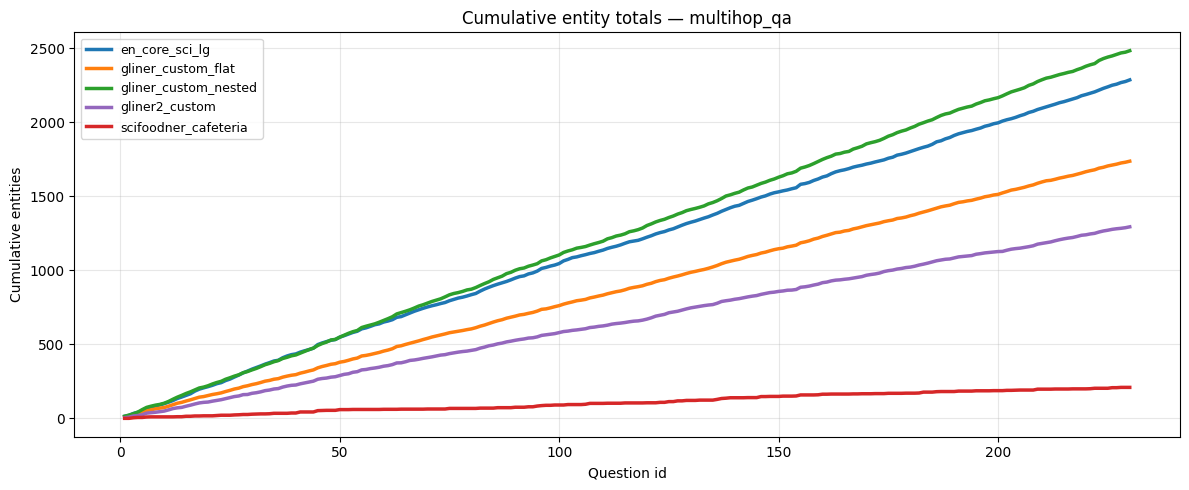

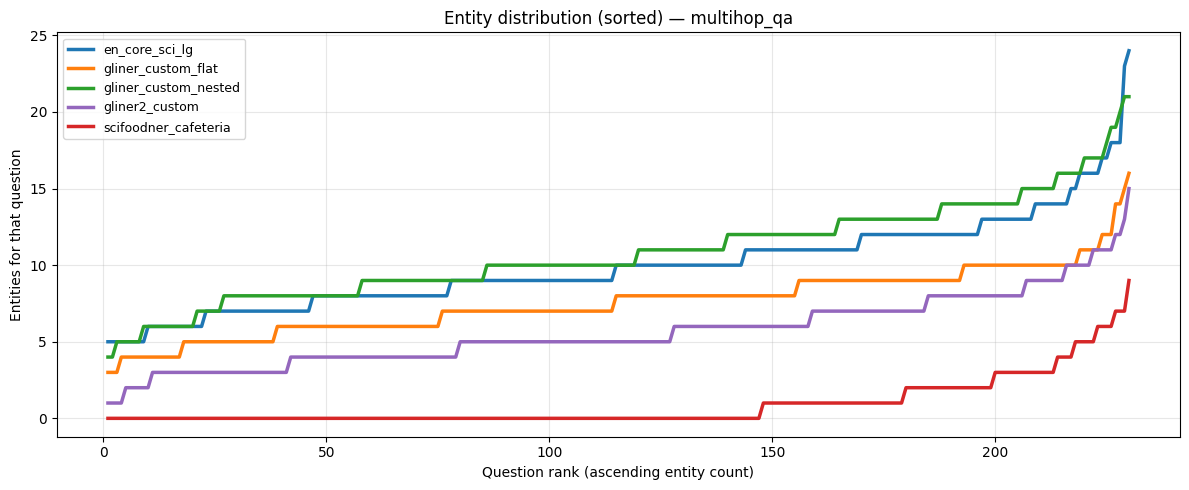

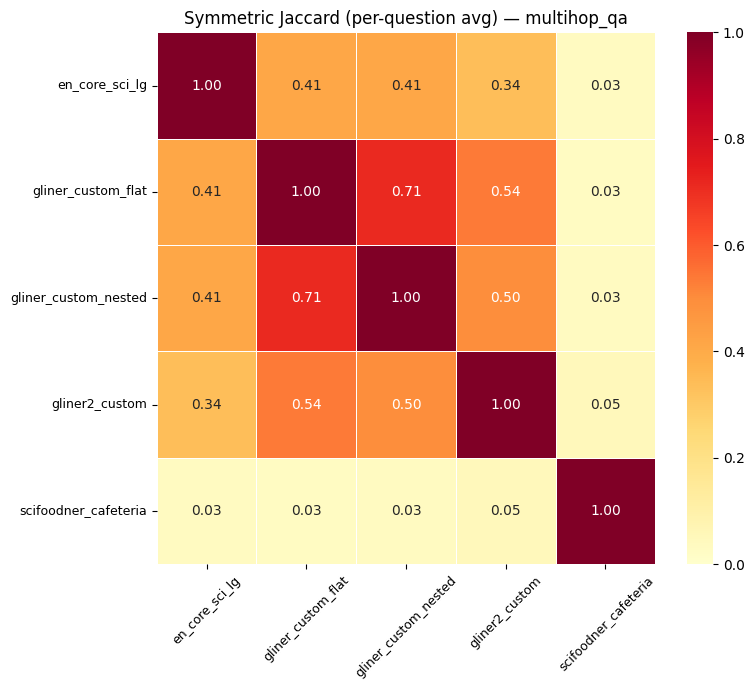

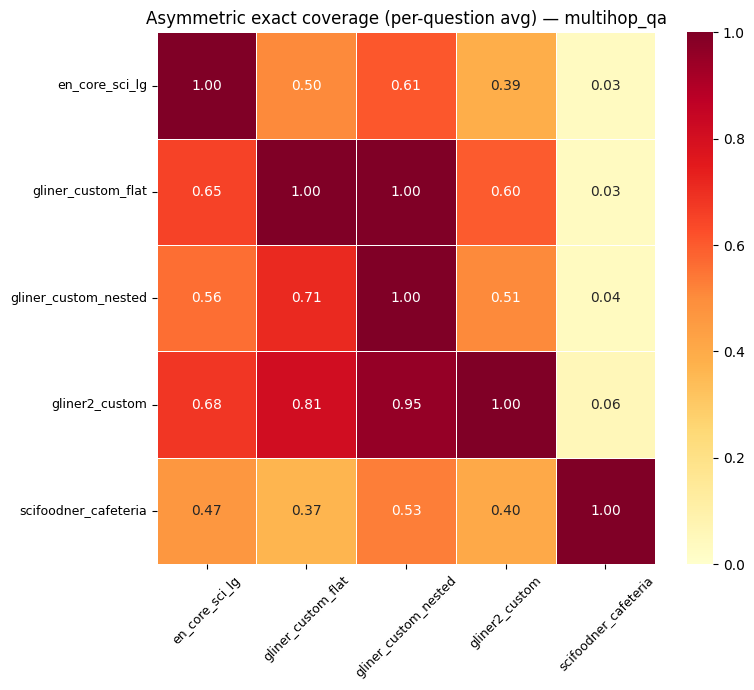

  Embedding 2136 unique entities...


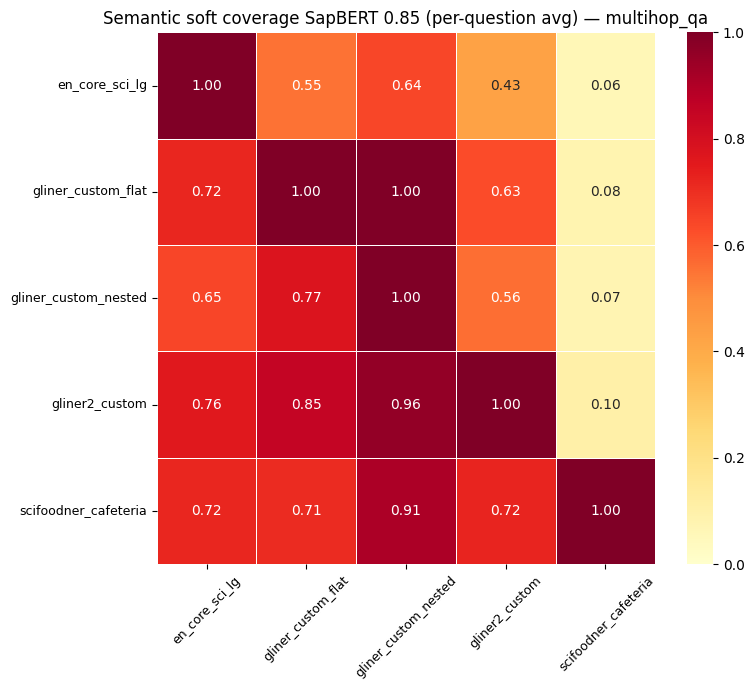

-----------------------------------------------------------------------------------------------
Q 101: How do the adult vitamin A intake recommendations differ between the typical daily requirement cited for men and women and the uniform 3,000 µg per day figure, and what safety considerations apply when meeting these amounts through animal sources versus beta‑carotene from plants?
  [sci_lg        ] ['adult', 'vitamin', 'intake', 'recommendations', 'daily', 'requirement', 'men', 'women', 'uniform', 'day', 'safety', 'considerations', 'meeting', 'amounts', 'animal', 'sources', 'beta‑carotene', 'plants']
  [gliner_flat   ] ['adult', 'vitamin\u202fa', 'intake recommendations', 'typical daily requirement', 'men', 'women', 'uniform 3,000\u202fµg per day', 'animal sources', 'beta‑carotene', 'plants']
  [gliner2       ] ['vitamin\u202fa', 'daily requirement', 'men', 'women', '3,000\u202fµg per day', 'beta‑carotene', 'plants']
  [scifoodner    ] []
----------------------------------------------

In [9]:
ds_name = "multihop_qa"
qs = DATASET_LOADERS[ds_name]()
ents = run_all_models_for_dataset(ds_name, qs)
met_multihop, qe_multihop = analyze_dataset(ds_name, qs, ents, _sap_tok, _sap_mdl)

---
## Dataset 2 — textbook_lyssari (268 questions)


=== textbook_lyssari (268 questions | gliner_batch=32) ===
    [MEM] SapBERT offloaded to CPU
    [CACHE] textbook_lyssari_en_core_sci_lg.csv
    [CACHE] textbook_lyssari_gliner_custom_flat.csv


    [CACHE] textbook_lyssari_gliner_custom_nested.csv
    [CACHE] textbook_lyssari_gliner2_custom.csv
    [CACHE] textbook_lyssari_scifoodner_cafeteria.csv


    [MEM] SapBERT restored to GPU


,model,zero_entity_questions,min_entities,max_entities,average_entities,median_entities,total_entities
0,en_core_sci_lg,0,1,9,3.66,4.0,982
1,gliner_custom_flat,0,1,8,3.74,4.0,1002
2,gliner_custom_nested,0,1,11,4.88,5.0,1307
3,gliner2_custom,32,0,5,1.55,1.0,415
4,scifoodner_cafeteria,245,0,2,0.09,0.0,24


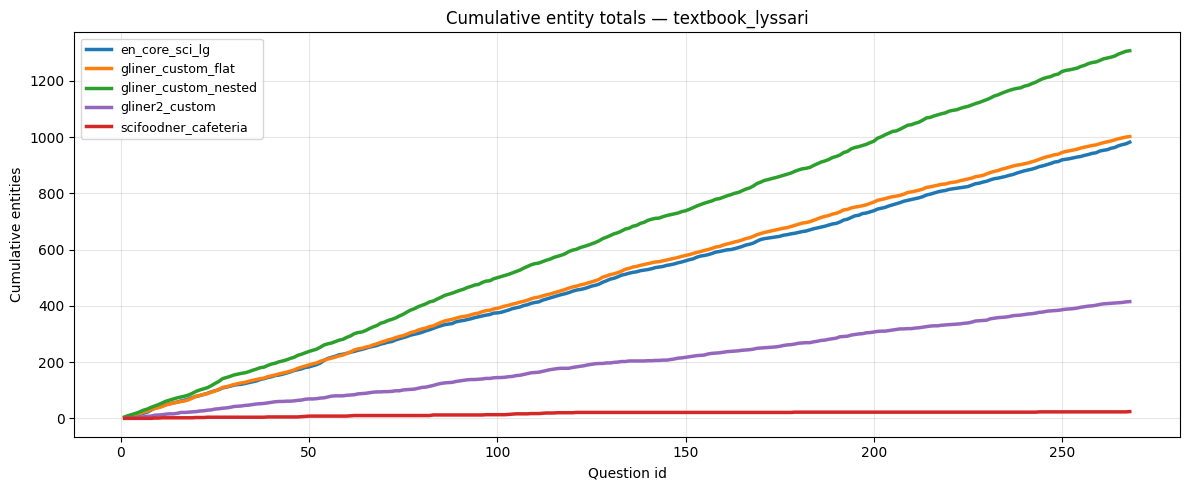

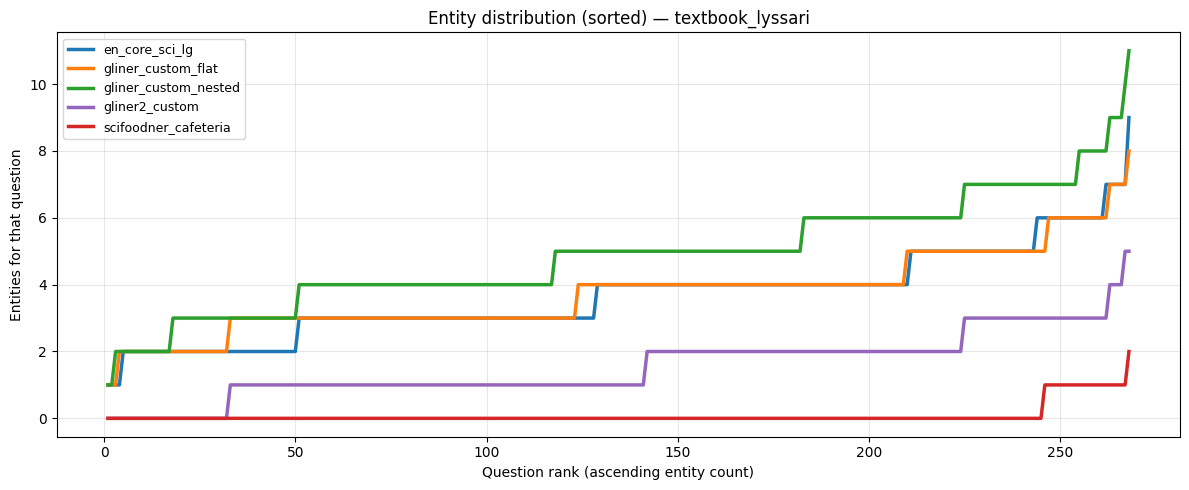

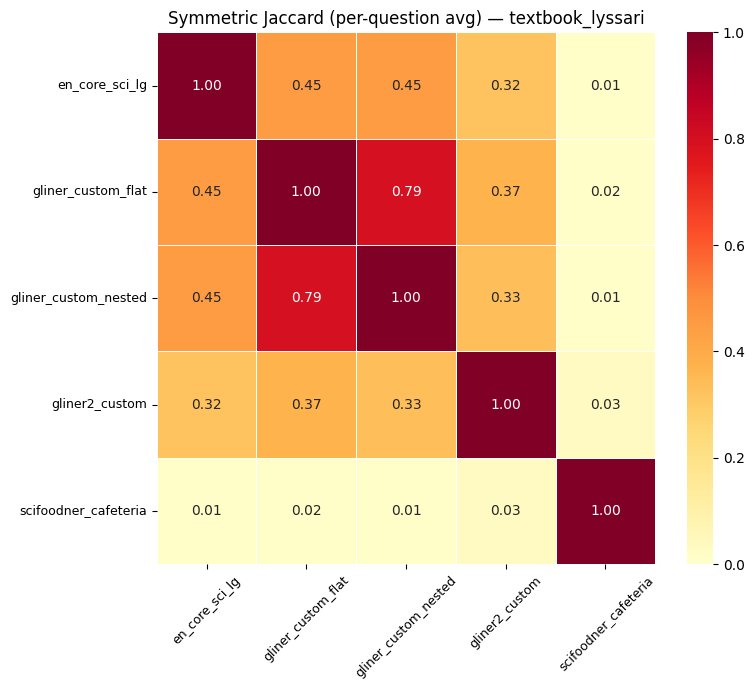

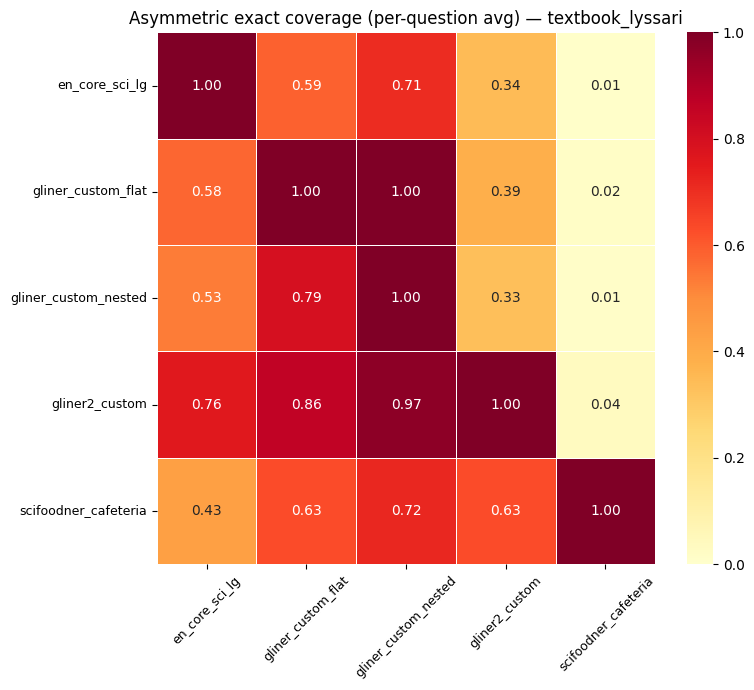

  Embedding 807 unique entities...


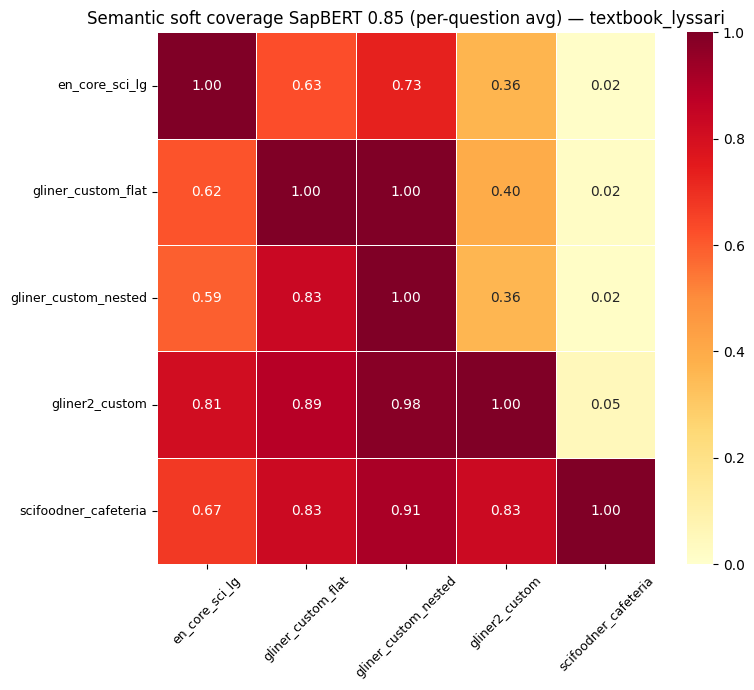

-----------------------------------------------------------------------------------------------
Q 128: What steps can individuals take to promote sustainability at home and reduce food waste?
  [sci_lg        ] ['steps', 'individuals', 'promote', 'sustainability', 'home', 'reduce', 'food waste']
  [gliner_flat   ] ['individuals', 'sustainability', 'home', 'and', 'reduce', 'food', 'waste', '?']
  [gliner2       ] []
  [scifoodner    ] []
-----------------------------------------------------------------------------------------------
Q  54: What are the potential risks associated with excessive intake of fat- soluble vitamins, specifically Vitamin A and D?
  [sci_lg        ] ['potential', 'risks', 'associated with', 'excessive', 'intake', 'fat-', 'soluble', 'vitamins', 'vitamin a']
  [gliner_flat   ] ['intake', 'fat- soluble vitamins', 'vitamin a', 'd']
  [gliner2       ] ['vitamin a']
  [scifoodner    ] []
----------------------------------------------------------------------------------

In [10]:
ds_name = "textbook_lyssari"
qs = DATASET_LOADERS[ds_name]()
ents = run_all_models_for_dataset(ds_name, qs)
met_textbook, qe_textbook = analyze_dataset(ds_name, qs, ents, _sap_tok, _sap_mdl)

---
## Dataset 3 — single_abstract (100 questions)


=== single_abstract (100 questions | gliner_batch=32) ===
    [MEM] SapBERT offloaded to CPU
    [CACHE] single_abstract_en_core_sci_lg.csv
    [CACHE] single_abstract_gliner_custom_flat.csv
    [CACHE] single_abstract_gliner_custom_nested.csv
    [CACHE] single_abstract_gliner2_custom.csv
    [CACHE] single_abstract_scifoodner_cafeteria.csv


    [MEM] SapBERT restored to GPU


,model,zero_entity_questions,min_entities,max_entities,average_entities,median_entities,total_entities
0,en_core_sci_lg,0,2,11,5.91,6.0,591
1,gliner_custom_flat,0,2,9,4.90,5.0,490
2,gliner_custom_nested,0,2,16,7.84,8.0,784
3,gliner2_custom,0,1,7,3.34,3.0,334
4,scifoodner_cafeteria,85,0,3,0.20,0.0,20


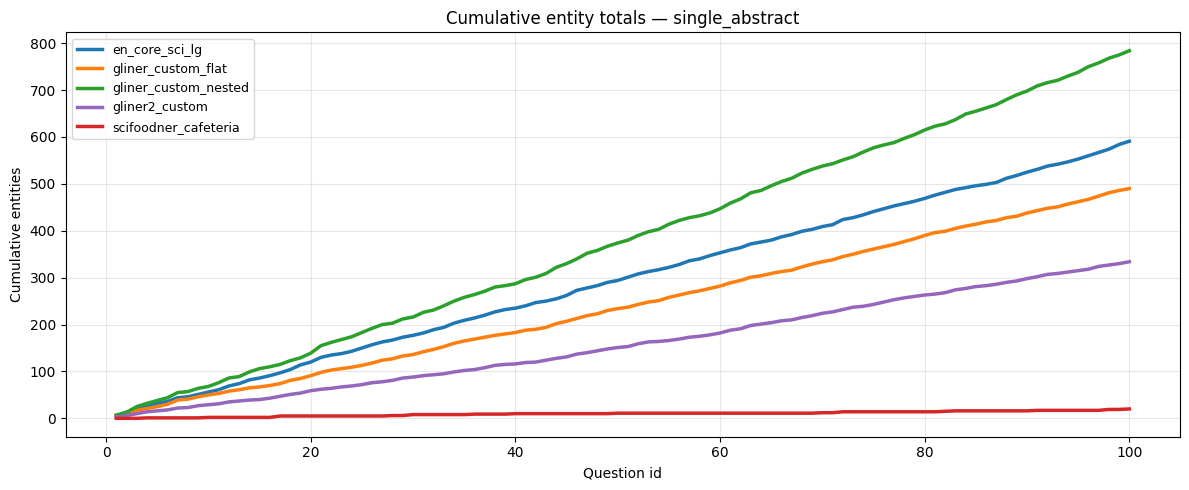

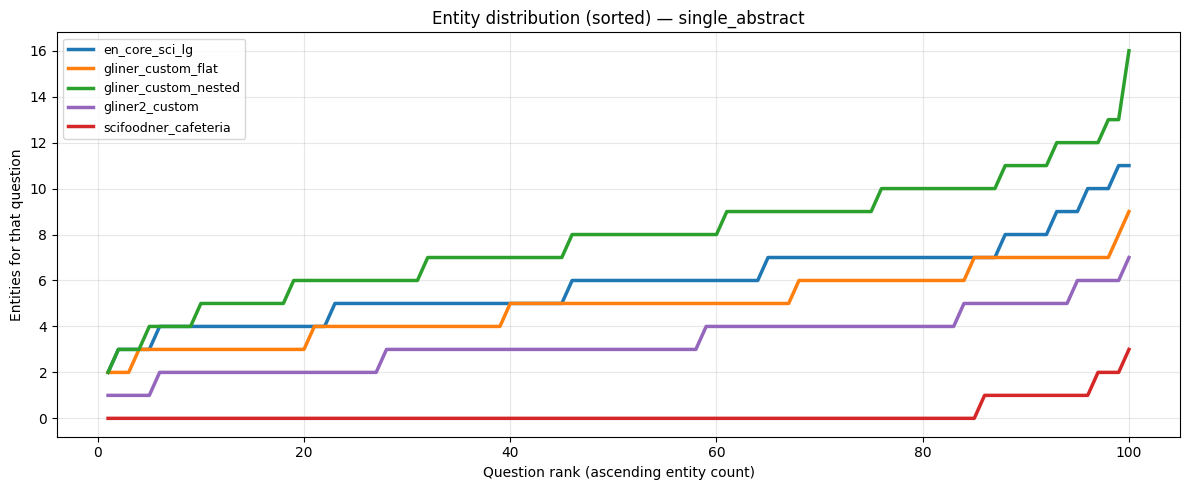

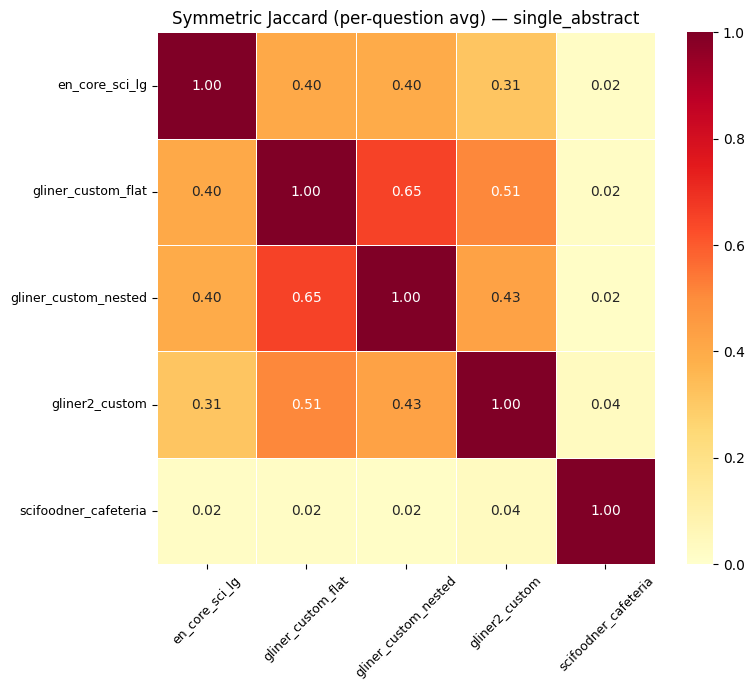

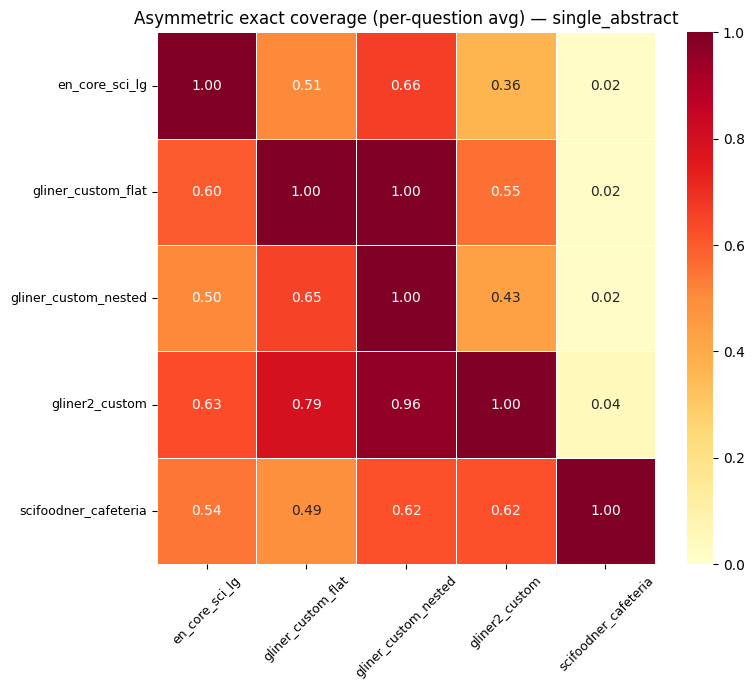

  Embedding 801 unique entities...


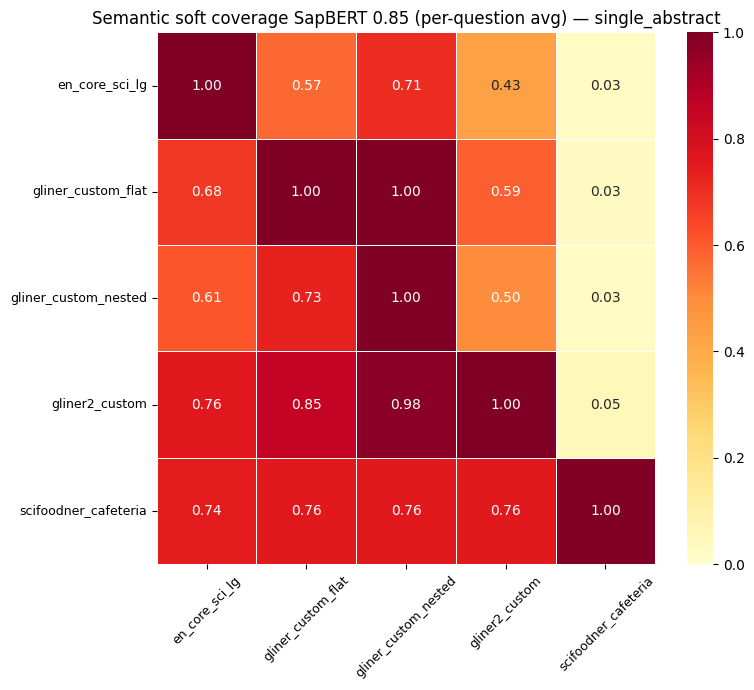

-----------------------------------------------------------------------------------------------
Q  46: What effect does a dairy fraction rich in milk fat globule membrane have on postprandial metabolic and inflammatory markers after a high‑fat meal in overweight and obese adults?
  [sci_lg        ] ['effect', 'dairy fraction', 'milk', 'fat globule membrane', 'postprandial', 'metabolic', 'inflammatory markers', 'high‑fat meal', 'overweight', 'obese', 'adults']
  [gliner_flat   ] ['dairy fraction', 'milk fat globule membrane', 'postprandial metabolic', 'inflammatory markers', 'high‑fat meal', 'overweight and obese adults']
  [gliner2       ] ['dairy fraction', 'milk fat globule membrane', 'postprandial metabolic', 'inflammatory markers', 'high‑fat meal', 'overweight and obese adults']
  [scifoodner    ] []
-----------------------------------------------------------------------------------------------
Q  21: Which sport’s female NCAA Division I athletes had perceived caloric needs that mo

In [11]:
ds_name = "single_abstract"
qs = DATASET_LOADERS[ds_name]()
ents = run_all_models_for_dataset(ds_name, qs)
met_abstract, qe_abstract = analyze_dataset(ds_name, qs, ents, _sap_tok, _sap_mdl)

---
## Dataset 4 — mmlu (344 nutrition questions)


=== mmlu (344 questions | gliner_batch=32) ===
    [MEM] SapBERT offloaded to CPU
    [CACHE] mmlu_en_core_sci_lg.csv
    [CACHE] mmlu_gliner_custom_flat.csv
    [CACHE] mmlu_gliner_custom_nested.csv
    [CACHE] mmlu_gliner2_custom.csv
    [CACHE] mmlu_scifoodner_cafeteria.csv


    [MEM] SapBERT restored to GPU


,model,zero_entity_questions,min_entities,max_entities,average_entities,median_entities,total_entities
0,en_core_sci_lg,0,1,13,3.99,3.0,1373
1,gliner_custom_flat,0,1,14,4.07,4.0,1401
2,gliner_custom_nested,0,1,22,5.39,5.0,1854
3,gliner2_custom,58,0,13,1.79,1.0,615
4,scifoodner_cafeteria,326,0,2,0.06,0.0,19


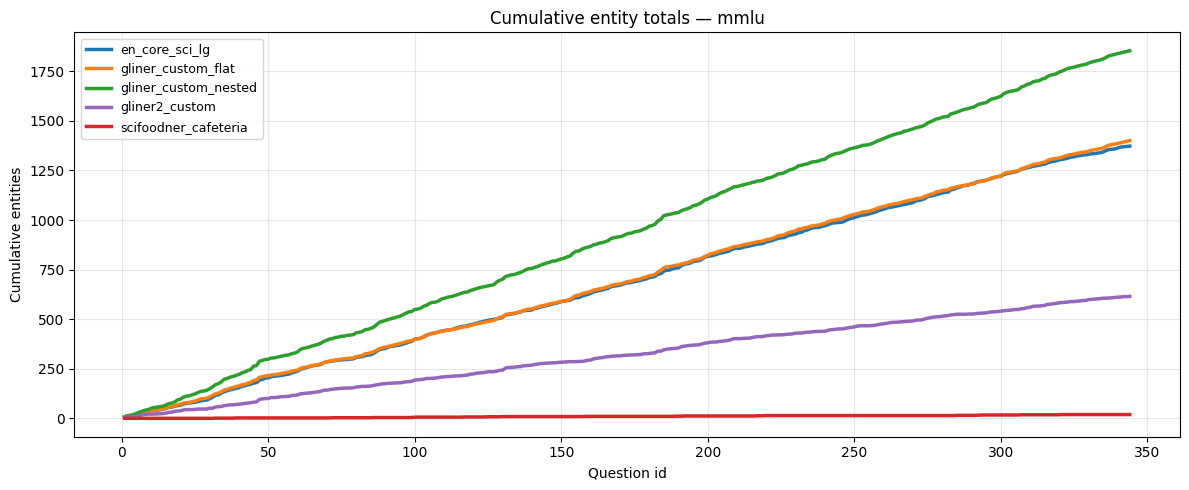

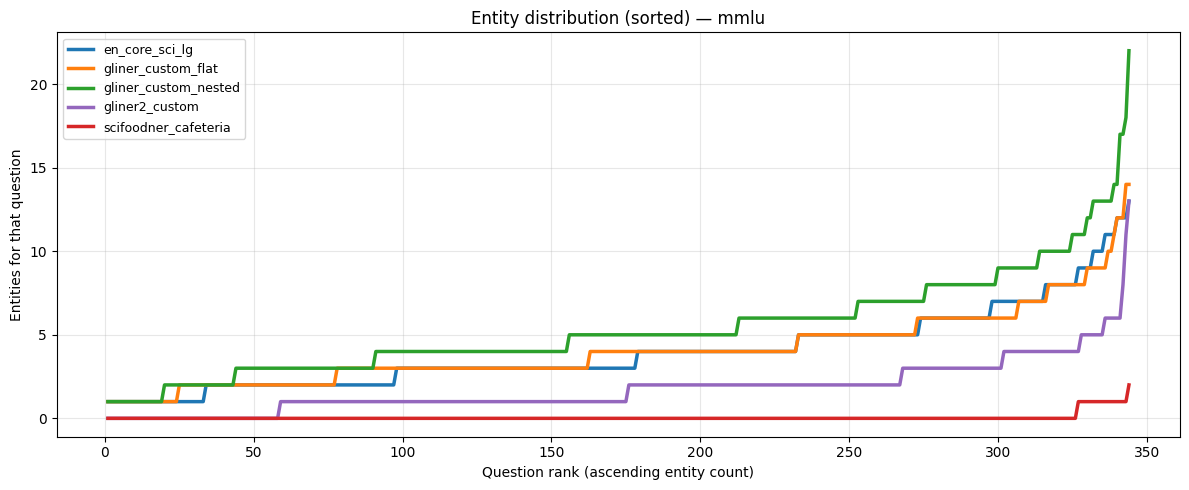

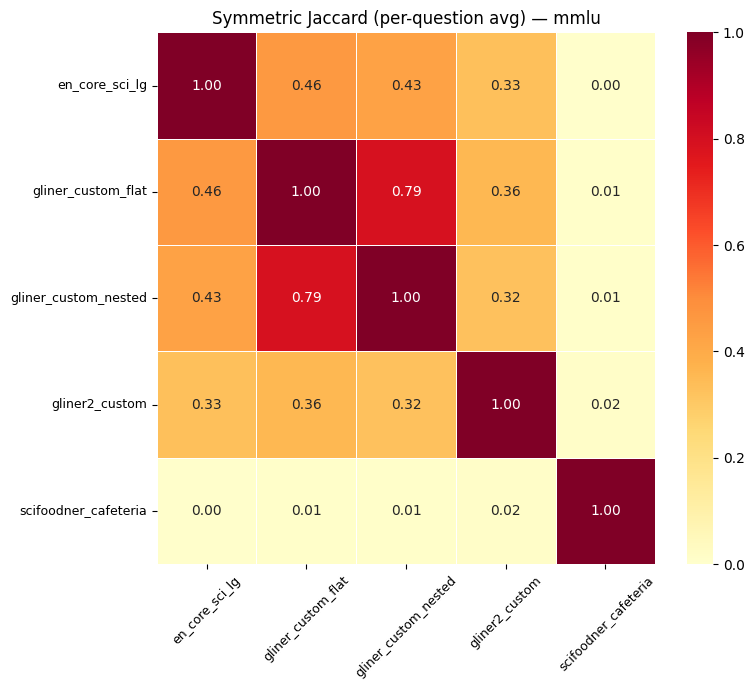

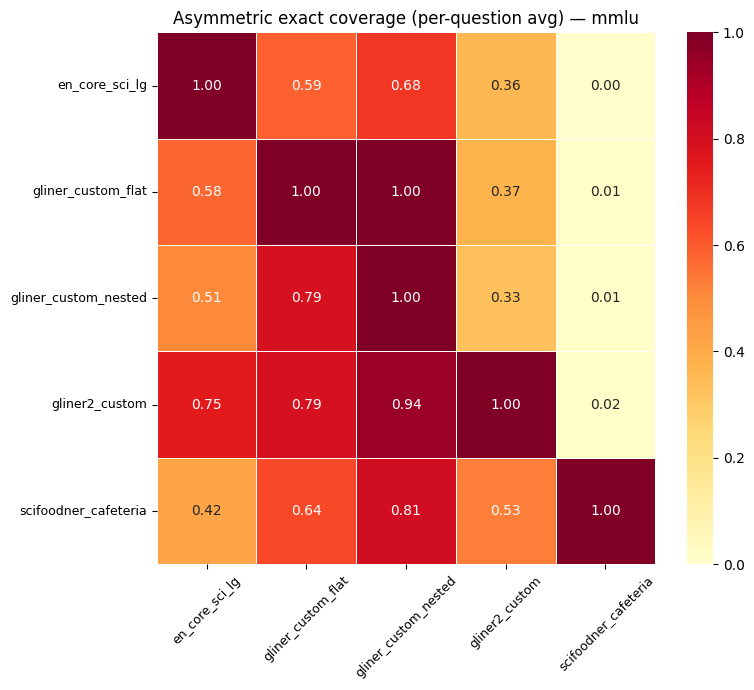

  Embedding 1317 unique entities...


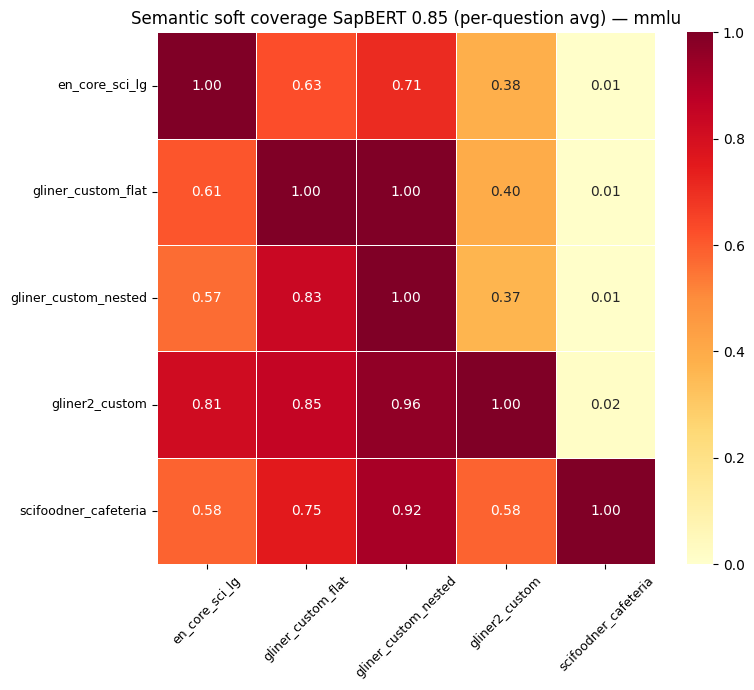

-----------------------------------------------------------------------------------------------
Q  47: Intestinal lactase deficiency leads to lactose maldigestion which subsequently can lead to lactose intolerance, i.e. causing clinical symptoms. Infants and children normally express sufficient lactase levels as not to experience clinical symptoms. Overall, adults can be classified as lactase-persisters or lactase non-persisters. What is the approximate percentage of Lactase non-persisters worldwide?
  [sci_lg        ] ['intestinal', 'lactase deficiency', 'lactose maldigestion', 'lactose intolerance', 'clinical symptoms', 'infants', 'children', 'lactase levels', 'adults', 'lactase-persisters', 'lactase', 'non-persisters', 'approximate']
  [gliner_flat   ] ['intestinal', 'lactase', 'deficiency', 'lactose', 'maldigestion', 'clinical symptoms', 'infants', 'children', 'levels', 'adults', 'lactase-persisters', 'non-persisters', 'percentage', 'worldwide']
  [gliner2       ] ['intestinal lact

In [12]:
ds_name = "mmlu"
qs = DATASET_LOADERS[ds_name]()
ents = run_all_models_for_dataset(ds_name, qs)
met_mmlu, qe_mmlu = analyze_dataset(ds_name, qs, ents, _sap_tok, _sap_mdl)

---
## Dataset 5 — hai_coaching (2 346 struggles)


=== hai_coaching (2346 questions | gliner_batch=16) ===
    [MEM] SapBERT offloaded to CPU
    [CACHE] hai_coaching_en_core_sci_lg.csv


    [CACHE] hai_coaching_gliner_custom_flat.csv


    [CACHE] hai_coaching_gliner_custom_nested.csv
    [CACHE] hai_coaching_gliner2_custom.csv
    [CACHE] hai_coaching_scifoodner_cafeteria.csv


    [MEM] SapBERT restored to GPU


,model,zero_entity_questions,min_entities,max_entities,average_entities,median_entities,total_entities
0,en_core_sci_lg,8,0,24,6.22,6.0,14596
1,gliner_custom_flat,0,1,19,6.55,6.0,15363
2,gliner_custom_nested,0,1,22,7.80,7.0,18294
3,gliner2_custom,144,0,14,2.46,2.0,5763
4,scifoodner_cafeteria,1305,0,10,0.88,0.0,2059


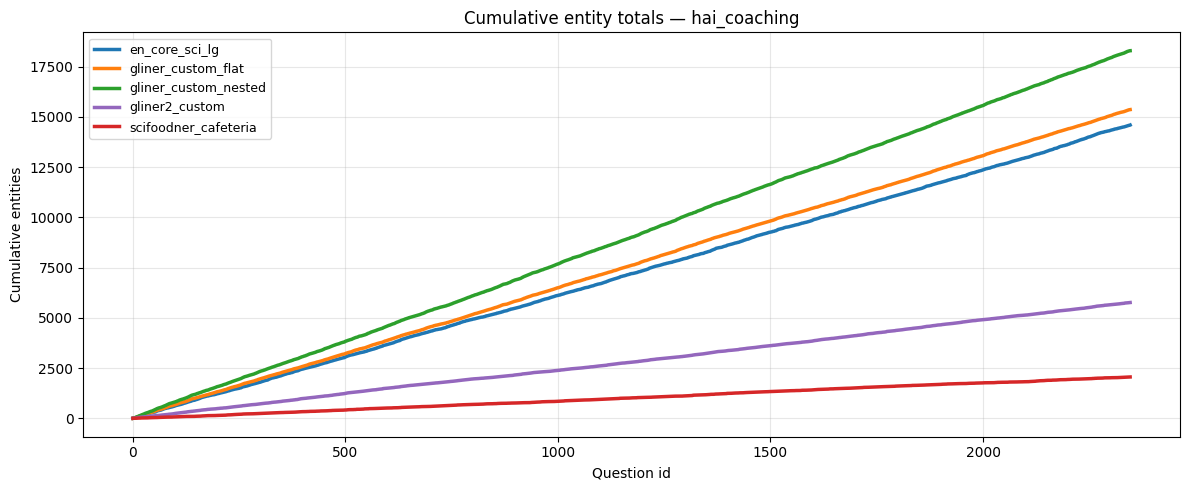

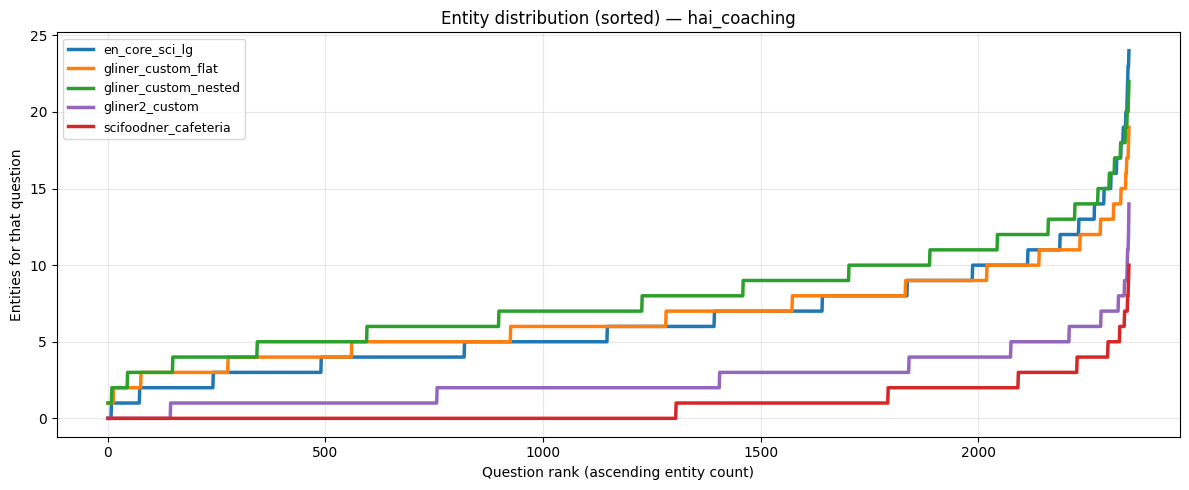

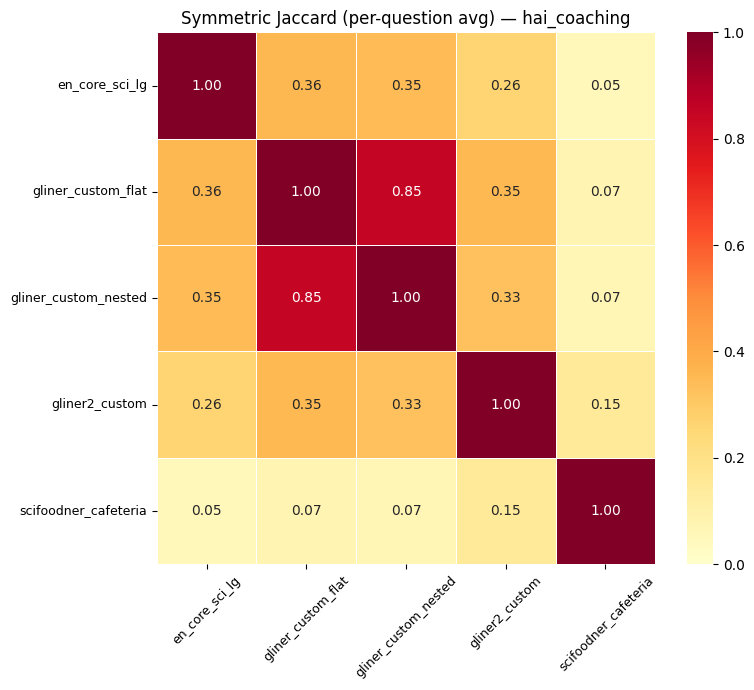

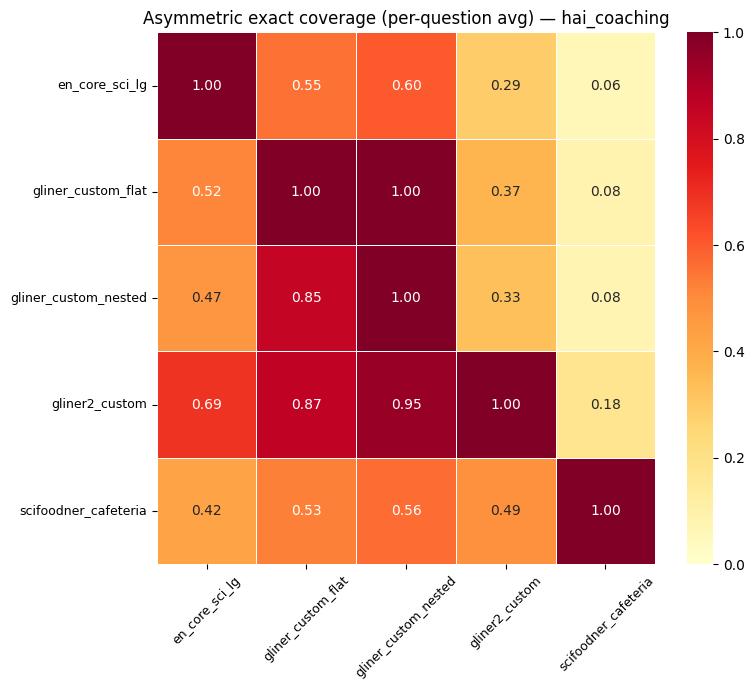

  Embedding 6484 unique entities...


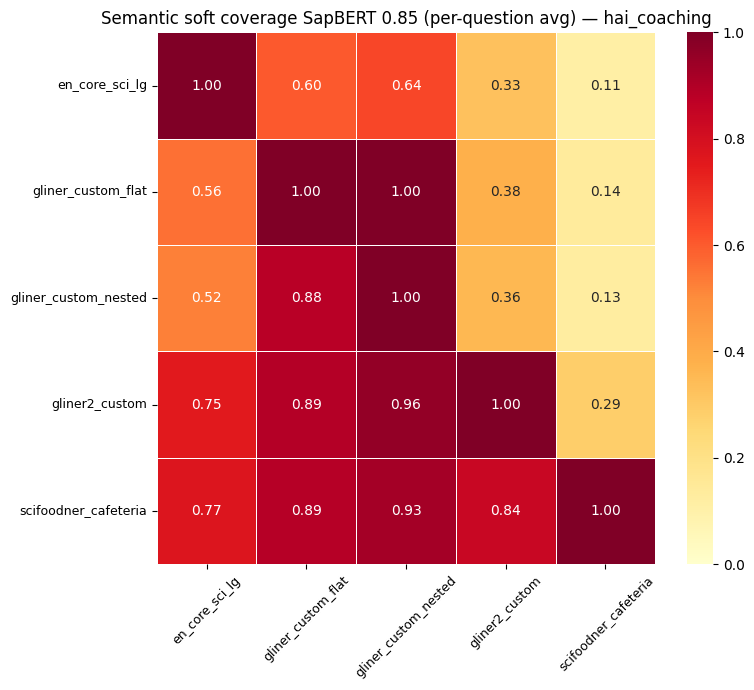

-----------------------------------------------------------------------------------------------
Q 630: I had a hard time learning how to have a proper nutrition since the information on the internet regarding women was also focused on "losing weight", "losing volume", "leaning out", and I was already skinny, with a lower muscular mass. When I started working out and dieting, I lost a ton of weight because I wasn't fueling my body properly because I felt like I had to cut out carbs at night, eating as little as possible, try out no-carb recipes, eating little to none protein, because that's what I saw other women do "to not get muscular like men". Also, my workouts were also not adjusted to my needs: I would try to do a lot of cardio and HIT, not gaining muscular mass.
  [sci_lg        ] ['hard time', 'nutrition', 'information', 'internet', 'women', 'losing weight', 'losing volume', 'skinny', 'lower', 'muscular', 'mass', 'dieting', 'lost', 'weight', 'cut out carbs', 'night', 'eating', '

In [13]:
ds_name = "hai_coaching"
qs = DATASET_LOADERS[ds_name]()
ents = run_all_models_for_dataset(ds_name, qs)
met_hai, qe_hai = analyze_dataset(ds_name, qs, ents, _sap_tok, _sap_mdl)

---
## Dataset 6 — ngqa (270 questions, 90 easy / 90 medium / 90 hard)



=== ngqa (270 questions | gliner_batch=32) ===
    [MEM] SapBERT offloaded to CPU
    [CACHE] ngqa_en_core_sci_lg.csv
    [CACHE] ngqa_gliner_custom_flat.csv


    [CACHE] ngqa_gliner_custom_nested.csv
    [CACHE] ngqa_gliner2_custom.csv
    [CACHE] ngqa_scifoodner_cafeteria.csv


    [MEM] SapBERT restored to GPU


,model,zero_entity_questions,min_entities,max_entities,average_entities,median_entities,total_entities
0,en_core_sci_lg,0,28,92,56.77,55.0,15327
1,gliner_custom_flat,0,11,39,23.80,23.0,6426
2,gliner_custom_nested,0,16,47,28.77,29.0,7767
3,gliner2_custom,0,10,38,22.04,22.0,5951
4,scifoodner_cafeteria,0,2,12,5.91,6.0,1595


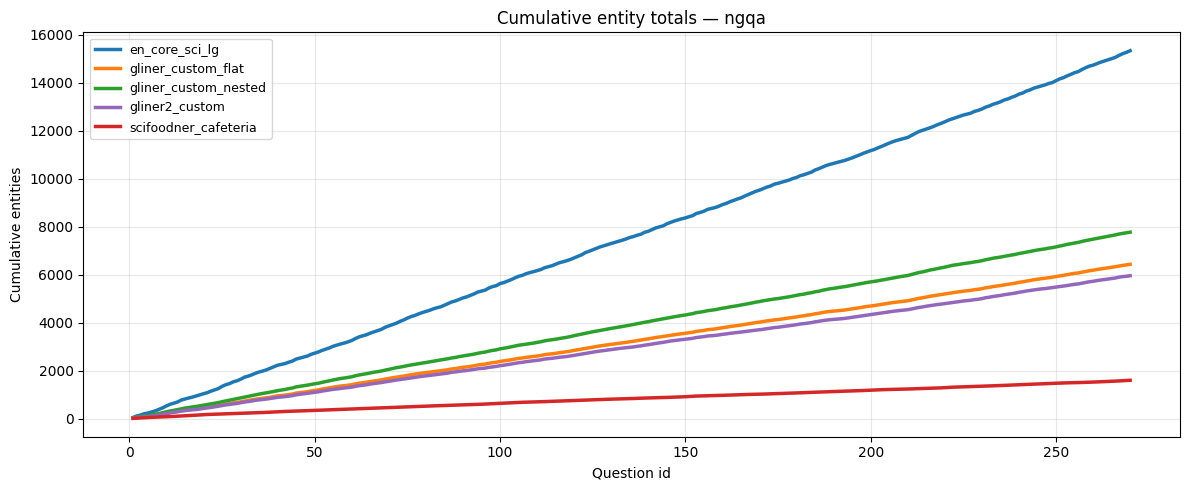

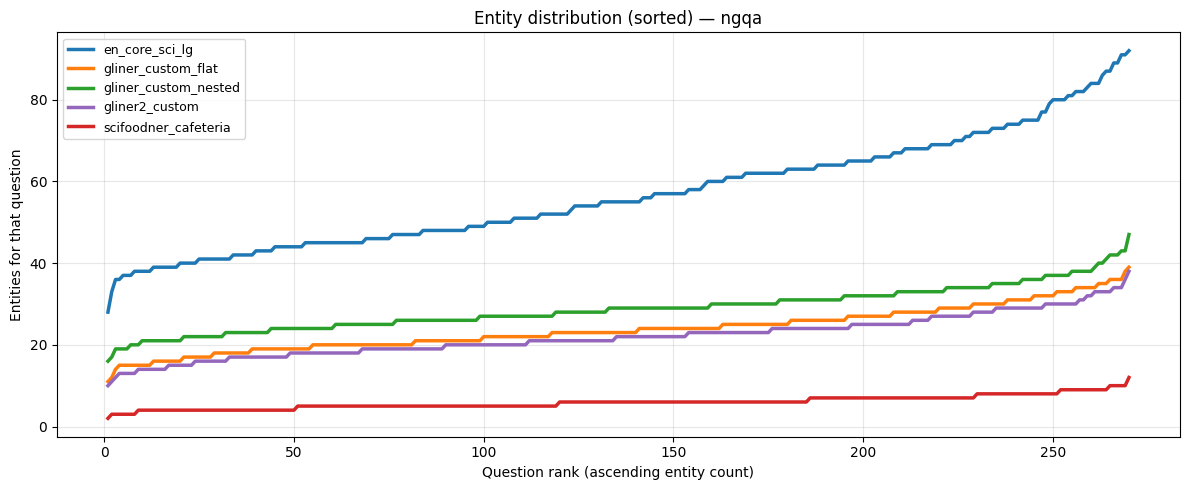

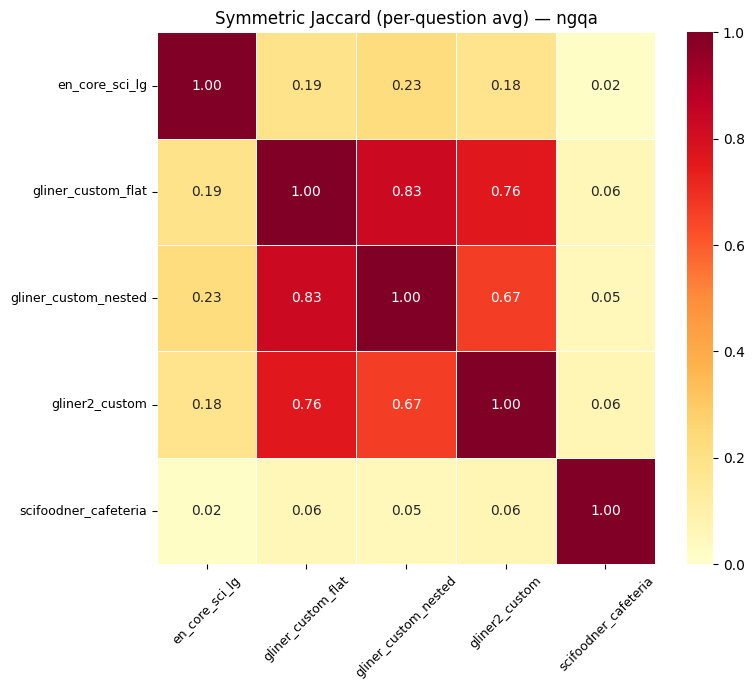

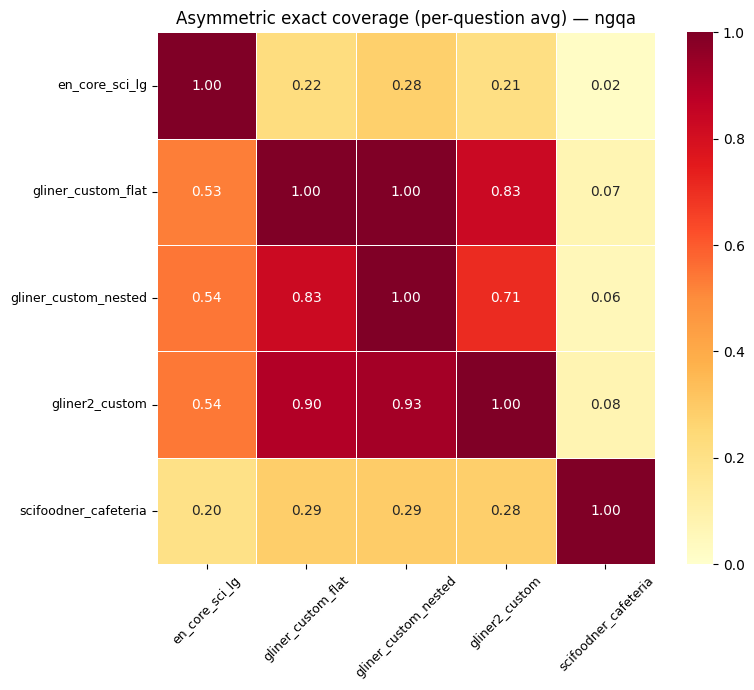

  Embedding 1478 unique entities...


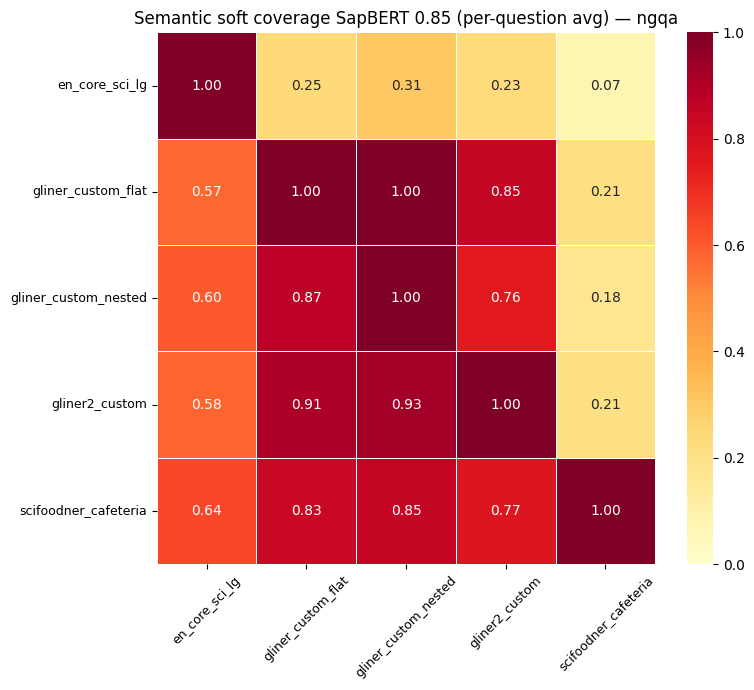

-----------------------------------------------------------------------------------------------
Q 123: A person has the following dietary and health profile:
- Drinks lots of milk;
- Eats little or no shellfish;
- Eats lots of fish;
- Adds little to no salt at table;
- Drinks Alcohol less than average;
- Eats few to no meals outside home;
- Eats few to no ready to eat meals;
- Takes few or no supplements;
- Uses lots of salt in preparation;
- Claims to have a good diet;
- Ate more food than usual;
- Ate less food than usual;
- Eats gluten free diet;
- Eats high protein diet;
- Has Low carbohydrate diet;
- Has High protein diet.

"Gumbo with rice" is a food that belongs to the category of Seafood mixed dishes. It contains the following ingredients: 
1) Okra, cooked, boiled, drained, without salt;
2) Pork, fresh, composite of trimmed retail cuts (leg, loin, and shoulder), separable lean only, cooked;
3) Crustaceans, shrimp, mixed species, raw (may contain additives to retain moisture);
4

,model,difficulty,avg_entities,zero_entity_q,n_questions
0,en_core_sci_lg,easy,58.66,0,90
1,en_core_sci_lg,hard,56.19,0,90
2,en_core_sci_lg,medium,55.46,0,90
3,gliner_custom_flat,easy,23.87,0,90
4,gliner_custom_flat,hard,23.99,0,90
5,gliner_custom_flat,medium,23.54,0,90
6,gliner_custom_nested,easy,28.19,0,90
7,gliner_custom_nested,hard,29.41,0,90
8,gliner_custom_nested,medium,28.70,0,90
9,gliner2_custom,easy,22.00,0,90


In [14]:
ds_name = "ngqa"
qs_ngqa = DATASET_LOADERS[ds_name]()
ents_ngqa = run_all_models_for_dataset(ds_name, qs_ngqa)
met_ngqa, qe_ngqa = analyze_dataset(ds_name, qs_ngqa[["question_id","question"]], ents_ngqa, _sap_tok, _sap_mdl)

# ── Difficulty-stratified entity statistics ───────────────────────────────────
diff_met = difficulty_metrics_table(qe_ngqa, qs_ngqa)
print("\n=== NGQA — entity stats by difficulty ===")
display(diff_met)
diff_met.to_csv(OUT_BASE / "ngqa" / "difficulty_metrics.csv", index=False)


---
## Cross-dataset comparison


=== Average entities per question — cross-dataset ===


,multihop_qa,textbook_lyssari,single_abstract,mmlu,hai_coaching,ngqa
model,,,,,,
en_core_sci_lg,9.93,3.66,5.91,3.99,6.22,56.77
gliner_custom_flat,7.55,3.74,4.90,4.07,6.55,23.80
gliner_custom_nested,10.79,4.88,7.84,5.39,7.80,28.77
gliner2_custom,5.62,1.55,3.34,1.79,2.46,22.04
scifoodner_cafeteria,0.91,0.09,0.20,0.06,0.88,5.91



=== Total entities — cross-dataset ===


,multihop_qa,textbook_lyssari,single_abstract,mmlu,hai_coaching,ngqa
model,,,,,,
en_core_sci_lg,2285,982,591,1373,14596,15327
gliner_custom_flat,1736,1002,490,1401,15363,6426
gliner_custom_nested,2482,1307,784,1854,18294,7767
gliner2_custom,1293,415,334,615,5763,5951
scifoodner_cafeteria,209,24,20,19,2059,1595


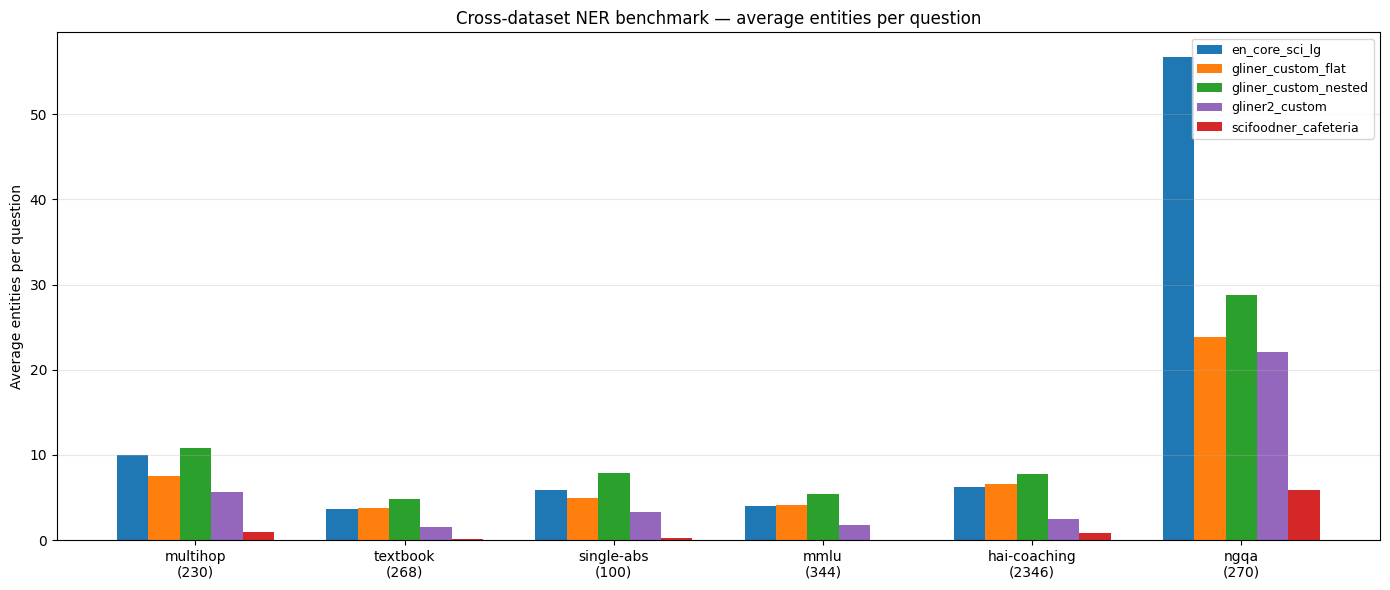


All cross-dataset outputs saved to /mnt/data/makis/wisefood/experiments/tests/ner_results/cross_dataset


In [15]:
# ── Cell 13: Cross-dataset summary ───────────────────────────────────────────
DATASET_LABELS = {
    "multihop_qa":      "multihop\n(230)",
    "textbook_lyssari": "textbook\n(268)",
    "single_abstract":  "single-abs\n(100)",
    "mmlu":             "mmlu\n(344)",
    "hai_coaching":     "hai-coaching\n(2346)",
    "ngqa":             "ngqa\n(270)",
}

met_by_ds = {
    "multihop_qa":      met_multihop,
    "textbook_lyssari": met_textbook,
    "single_abstract":  met_abstract,
    "mmlu":             met_mmlu,
    "hai_coaching":     met_hai,
    "ngqa":             met_ngqa,
}

# Table: rows = models, cols = datasets, cell = avg_entities
avg_table = pd.DataFrame(
    {ds: met.set_index("model")["average_entities"] for ds, met in met_by_ds.items()}
).reindex(ALL_MODELS)
avg_table.columns = list(DATASET_LABELS.keys())

print("\n=== Average entities per question — cross-dataset ===")
display(avg_table.round(2))
avg_table.round(3).to_csv(OUT_BASE / "cross_dataset_avg_entities.csv")

# Total entities table
total_table = pd.DataFrame(
    {ds: met.set_index("model")["total_entities"] for ds, met in met_by_ds.items()}
).reindex(ALL_MODELS)
total_table.columns = list(DATASET_LABELS.keys())
print("\n=== Total entities — cross-dataset ===")
display(total_table)
total_table.to_csv(OUT_BASE / "cross_dataset_total_entities.csv")

# Grouped bar chart — avg entities
ds_keys = list(DATASET_LABELS.keys())
x = np.arange(len(ds_keys))
width = 0.15
fig, ax = plt.subplots(figsize=(14, 6))
for i, model in enumerate(ALL_MODELS):
    vals = [avg_table.loc[model, ds] for ds in ds_keys]
    ax.bar(x + i*width, vals, width, label=model, color=MODEL_COLORS[model])
ax.set_xticks(x + width*2)
ax.set_xticklabels([DATASET_LABELS[d] for d in ds_keys], fontsize=10)
ax.set_ylabel("Average entities per question")
ax.set_title("Cross-dataset NER benchmark — average entities per question")
ax.legend(fontsize=9, loc="upper right")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(OUT_BASE / "cross_dataset_avg_entities.png", dpi=200, bbox_inches="tight")
plt.show()

# Clean up SapBERT
del _sap_mdl; torch.cuda.empty_cache()
print(f"\nAll cross-dataset outputs saved to {OUT_BASE}")

---
## GPT-4o-mini Gold-Standard Comparison (RQ4 baseline)

Samples **100 questions per dataset (590 total: 100×5 datasets + 90 stratified NGQA)** and extracts entities via
**GPT-4o-mini** (FoodScholar prompt, OpenRouter) as an approximate gold standard.  
Each NER variant is then scored against the GPT reference using
**SapBERT cosine similarity** (threshold = 0.85) to allow fuzzy matching
(`"nutrient"` ↔ `"nutrients"`, `"omega-3 fatty acid"` ↔ `"DHA"`, etc.).

**Metrics:** semantic **recall**, **precision**, and **F1** vs GPT-4o-mini, reported
per dataset and as a cross-dataset MEAN (the "heat column").

In [16]:
# ── Cell 15: Sample questions + reload SapBERT ───────────────────────────────
SAMPLE_PER_DATASET = 100          # 100 per dataset × 5 datasets + 90 stratified NGQA = 590 total
RANDOM_SEED        = 42
SAMPLE_DATASETS    = ["multihop_qa", "textbook_lyssari", "single_abstract", "mmlu", "hai_coaching", "ngqa"]

np.random.seed(RANDOM_SEED)

# Build per-dataset samples with GLOBALLY UNIQUE question_ids across all datasets
sampled_frames = {}
q_offset = 0
for ds_name in SAMPLE_DATASETS:
    df = DATASET_LOADERS[ds_name]()
    if ds_name == "ngqa" and "difficulty" in df.columns:
        # Stratified: 30 per difficulty level (easy / medium / hard) = 90 total
        NGQA_PER_DIFF = 30
        pieces = []
        for diff, grp in df.groupby("difficulty"):
            pieces.append(grp.sample(n=min(NGQA_PER_DIFF, len(grp)), random_state=RANDOM_SEED))
        sdf = pd.concat(pieces).copy().reset_index(drop=True)
        sdf["question_id"] = range(q_offset + 1, q_offset + 1 + len(sdf))
        sdf["dataset"] = ds_name
        sampled_frames[ds_name] = sdf[["question_id", "question", "dataset", "difficulty"]]
        q_offset += len(sdf)
    else:
        n   = min(SAMPLE_PER_DATASET, len(df))
        sdf = df.sample(n=n, random_state=RANDOM_SEED).copy().reset_index(drop=True)
        sdf["question_id"] = range(q_offset + 1, q_offset + 1 + n)
        sdf["dataset"]     = ds_name
        sampled_frames[ds_name] = sdf[["question_id", "question", "dataset"]]
        q_offset += n

all_sampled = (pd.concat(list(sampled_frames.values()), ignore_index=True)
               .reset_index(drop=True))
# difficulty column exists only for ngqa rows; fill NaN for other datasets
if "difficulty" not in all_sampled.columns:
    all_sampled["difficulty"] = np.nan
else:
    all_sampled["difficulty"] = all_sampled["difficulty"].fillna("n/a")

print(f"Total sampled: {len(all_sampled)} questions  (SAMPLE_PER_DATASET={SAMPLE_PER_DATASET})")
for ds, df in sampled_frames.items():
    lo, hi = df["question_id"].min(), df["question_id"].max()
    print(f"  {ds}: {len(df)} questions  (ids {lo}–{hi})")

# ── Reload SapBERT if it was deleted at the end of Cell 13 ───────────────────
try:
    _ = _sap_mdl.config           # will NameError if deleted
    _sap_mdl = _sap_mdl.to(device).eval()
    print("\nSapBERT already in memory — moved to GPU.")
except NameError:
    print("\nReloading SapBERT...")
    from transformers import AutoTokenizer, AutoModel
    _sap_tok = AutoTokenizer.from_pretrained(SAPBERT_MODEL)
    _sap_mdl = AutoModel.from_pretrained(SAPBERT_MODEL).to(device).eval()
    print("SapBERT ready.")

Total sampled: 590 questions  (SAMPLE_PER_DATASET=100)
  multihop_qa: 100 questions  (ids 1–100)
  textbook_lyssari: 100 questions  (ids 101–200)
  single_abstract: 100 questions  (ids 201–300)
  mmlu: 100 questions  (ids 301–400)
  hai_coaching: 100 questions  (ids 401–500)
  ngqa: 90 questions  (ids 501–590)

Reloading SapBERT...


SapBERT ready.


In [17]:
# ── Cell 16: GPT-4o-mini entity extraction via OpenRouter ────────────────────
import requests, json as _json, time

# ─────────────────────────────────────────────────────────────────────────────
OPENROUTER_API_KEY = "<OPENROUTER_API_KEY_REDACTED>"   # <── paste key here
# ─────────────────────────────────────────────────────────────────────────────

OPENROUTER_MODEL = "openai/gpt-4o-mini"
OPENROUTER_URL   = "https://openrouter.ai/api/v1/chat/completions"

FOODSCHOLAR_SYSTEM = (
    "You are FoodScholar, a scientific Q&A assistant specializing in nutrition, "
    "healthy and sustainable diets, and food waste prevention. "
    "Find the entities related to these topics in the question."
)

# Cache path is n-aware so n=25 and n=100 results never collide
GPT_ENTITY_CACHE = OUT_BASE / "cache" / f"gpt4omini_entities_n{SAMPLE_PER_DATASET}.json"


def extract_entities_gpt(question: str, api_key: str, retries: int = 3) -> list:
    """Call GPT-4o-mini via OpenRouter and return a list of entity strings."""
    prompt = (
        "Extract all named entities from the following question that are relevant to "
        "nutrition, food items, dietary patterns, health conditions, biomarkers, nutrients, "
        "food waste, or sustainability.\n"
        "Return ONLY a JSON array of entity strings — no explanation — e.g.: "
        '["olive oil", "omega-3", "cardiovascular disease"]\n\n'
        f"Question: {question}"
    )
    headers = {
        "Authorization": f"Bearer {api_key}",
        "Content-Type": "application/json",
        "HTTP-Referer": "https://wisefood-project.eu",
        "X-Title": "FoodScholar NER Benchmark",
    }
    payload = {
        "model": OPENROUTER_MODEL,
        "messages": [
            {"role": "system", "content": FOODSCHOLAR_SYSTEM},
            {"role": "user",   "content": prompt},
        ],
        "temperature": 0.0,
        "max_tokens": 300,
    }
    for attempt in range(retries):
        try:
            resp = requests.post(OPENROUTER_URL, headers=headers,
                                 json=payload, timeout=30)
            resp.raise_for_status()
            content = resp.json()["choices"][0]["message"]["content"].strip()
            start, end = content.find("["), content.rfind("]") + 1
            if start >= 0 and end > start:
                return _json.loads(content[start:end])
            return []
        except Exception as exc:
            print(f"    [GPT] attempt {attempt + 1} failed: {exc}")
            time.sleep(2 ** attempt)
    return []


def run_gpt_on_sampled(sampled_df, api_key, cache_path=None):
    """Extract GPT entities for all sampled questions, with JSON caching."""
    cache_path = Path(cache_path or GPT_ENTITY_CACHE)
    if cache_path.exists():
        print(f"[CACHE] GPT-4o-mini entities from {cache_path}")
        with open(cache_path, encoding="utf-8") as f:
            return _json.load(f)

    if api_key.startswith("PLACEHOLDER"):
        raise RuntimeError(
            "No cached GPT entities found and OPENROUTER_API_KEY is not set.\n"
            "Paste your OpenRouter key into the OPENROUTER_API_KEY variable above."
        )

    results = {}
    total = len(sampled_df)
    for _, row in sampled_df.iterrows():
        qid = int(row["question_id"])
        key = str(qid)
        print(f"  GPT Q{qid}/{total}  [{row['dataset']}]: {str(row['question'])[:65]}...")
        entities = extract_entities_gpt(str(row["question"]), api_key)
        results[key] = {
            "question_id": qid,
            "dataset":     row["dataset"],
            "question":    str(row["question"]),
            "entities":    entities,
        }
        time.sleep(0.35)    # polite rate-limit pause

    with open(cache_path, "w", encoding="utf-8") as f:
        _json.dump(results, f, indent=2, ensure_ascii=False)
    print(f"Saved {len(results)} GPT entity sets → {cache_path}")
    return results


gpt_entities = run_gpt_on_sampled(all_sampled, OPENROUTER_API_KEY)
print(f"\nGPT-4o-mini: {len(gpt_entities)} questions processed.")
for sid, info in list(gpt_entities.items())[:3]:
    print(f"  Q{info['question_id']} [{info['dataset']}]: {info['entities']}")

[CACHE] GPT-4o-mini entities from /mnt/data/makis/wisefood/experiments/tests/ner_results/cross_dataset/cache/gpt4omini_entities_n100.json

GPT-4o-mini: 590 questions processed.
  Q1 [multihop_qa]: ['high-protein diet', 'animal protein', 'plant protein', 'bone health', 'kidney health', 'dietary sulfur', 'urinary calcium']
  Q2 [multihop_qa]: ['carbohydrates', 'food flavor', 'texture', 'bulk', 'preservation', 'mucus lubrication', 'cell-to-cell communication', 'weight-management']
  Q3 [multihop_qa]: ['folate', 'hematologic changes', 'colon cancer']


In [18]:
# ── Cell 17: NER variants on sampled questions (with per-model caching) ───────
# Cache dir is n-aware so different sample sizes live in separate folders
SAMPLED_CACHE_DIR = OUT_BASE / "cache" / f"sampled_n{SAMPLE_PER_DATASET}"
SAMPLED_CACHE_DIR.mkdir(exist_ok=True)

sampled_ents_pieces = []

for ds_name in SAMPLE_DATASETS:
    # Use only question_id + question columns so NER runners get clean input
    q_df = sampled_frames[ds_name][["question_id", "question"]].copy()
    print(f"\n--- {ds_name}  ({len(q_df)} questions, ids "
          f"{q_df['question_id'].min()}–{q_df['question_id'].max()}) ---")

    _sapbert_to_cpu()   # free GPU memory before loading NER models

    # Default-arg trick captures the current q_df value per loop iteration
    model_runners = [
        ("en_core_sci_lg",
         lambda d=q_df: scispacy_rows(d)),
        ("gliner_custom_flat",
         lambda d=q_df: gliner_rows(d, flat_ner=True, run_name="gliner_custom_flat")),
        ("gliner_custom_nested",
         lambda d=q_df: gliner_rows(d, flat_ner=False, run_name="gliner_custom_nested")),
        ("gliner2_custom",
         lambda d=q_df: gliner2_rows(d)),
        ("scifoodner_cafeteria",
         lambda d=q_df: scifoodner_rows(d)),
    ]

    for model_tag, fn in model_runners:
        cache_p = SAMPLED_CACHE_DIR / f"{ds_name}_{model_tag}.csv"
        piece   = run_or_load(cache_p, fn).copy()
        piece["dataset"] = ds_name
        sampled_ents_pieces.append(piece)

all_sampled_ents = pd.concat(sampled_ents_pieces, ignore_index=True)
print(f"\nTotal NER entity rows across sampled questions: {len(all_sampled_ents)}")

_sapbert_to_gpu()   # restore SapBERT to GPU for the analysis cells below


--- multihop_qa  (100 questions, ids 1–100) ---
    [MEM] SapBERT offloaded to CPU
    [CACHE] multihop_qa_en_core_sci_lg.csv
    [CACHE] multihop_qa_gliner_custom_flat.csv


    [CACHE] multihop_qa_gliner_custom_nested.csv
    [CACHE] multihop_qa_gliner2_custom.csv


    [CACHE] multihop_qa_scifoodner_cafeteria.csv

--- textbook_lyssari  (100 questions, ids 101–200) ---
    [CACHE] textbook_lyssari_en_core_sci_lg.csv


    [CACHE] textbook_lyssari_gliner_custom_flat.csv


    [CACHE] textbook_lyssari_gliner_custom_nested.csv
    [CACHE] textbook_lyssari_gliner2_custom.csv
    [CACHE] textbook_lyssari_scifoodner_cafeteria.csv

--- single_abstract  (100 questions, ids 201–300) ---
    [CACHE] single_abstract_en_core_sci_lg.csv
    [CACHE] single_abstract_gliner_custom_flat.csv
    [CACHE] single_abstract_gliner_custom_nested.csv
    [CACHE] single_abstract_gliner2_custom.csv
    [CACHE] single_abstract_scifoodner_cafeteria.csv

--- mmlu  (100 questions, ids 301–400) ---
    [CACHE] mmlu_en_core_sci_lg.csv
    [CACHE] mmlu_gliner_custom_flat.csv
    [CACHE] mmlu_gliner_custom_nested.csv
    [CACHE] mmlu_gliner2_custom.csv
    [CACHE] mmlu_scifoodner_cafeteria.csv

--- hai_coaching  (100 questions, ids 401–500) ---
    [CACHE] hai_coaching_en_core_sci_lg.csv
    [CACHE] hai_coaching_gliner_custom_flat.csv
    [CACHE] hai_coaching_gliner_custom_nested.csv
    [CACHE] hai_coaching_gliner2_custom.csv
    [CACHE] hai_coaching_scifoodner_cafeteria.csv

--- ngqa 

    [CACHE] ngqa_gliner_custom_flat.csv


    [CACHE] ngqa_gliner_custom_nested.csv
    [CACHE] ngqa_gliner2_custom.csv
    [CACHE] ngqa_scifoodner_cafeteria.csv

Total NER entity rows across sampled questions: 25213


    [MEM] SapBERT restored to GPU


In [19]:
# ── Cell 18: SapBERT semantic recall vs GPT-4o-mini ──────────────────────────
#
# For each (NER variant, dataset, question) triple we compute:
#   recall = |{GPT entities semantically matched by some NER entity}| / |GPT entities|
# where "semantically matched" means SapBERT cosine similarity >= SEM_THRESHOLD (0.85).
# Questions where GPT found nothing are skipped (NaN) to avoid deflating scores.
# The per-model, per-dataset score is the mean over valid questions.

# ── 1. Build lookup: question_id → GPT entity list (lowercased) ──────────────
gpt_ents_by_qid = {}
for sid, info in gpt_entities.items():
    qid = info["question_id"]
    gpt_ents_by_qid[qid] = [
        e.lower().strip() for e in info["entities"]
        if isinstance(e, str) and e.strip()
    ]

# ── 2. Build NER entity lookup from sampled results ──────────────────────────
sampled_q_meta = all_sampled[["question_id", "question"]].drop_duplicates()
sampled_qe_ner = question_entities_frame(sampled_q_meta, all_sampled_ents)
sampled_qe_ner["entity_count"] = sampled_qe_ner["entities"].str.len()
qid_to_ds = all_sampled.set_index("question_id")["dataset"].to_dict()
sampled_qe_ner["dataset"] = sampled_qe_ner["question_id"].map(qid_to_ds)

# Indexed for fast (qid, model) lookup
ner_ent_idx = sampled_qe_ner.set_index(["question_id", "model"])["entities"]

# ── 3. Embed all unique entities once ────────────────────────────────────────
all_unique_ents = set()
for ents in gpt_ents_by_qid.values():
    all_unique_ents.update(ents)
for ents_list in sampled_qe_ner["entities"]:
    if isinstance(ents_list, list):
        all_unique_ents.update(
            e.lower().strip() for e in ents_list
            if isinstance(e, str) and e.strip()
        )

all_unique_list = [e for e in all_unique_ents if e]
print(f"Embedding {len(all_unique_list)} unique entity strings...")
vecs = _embed(all_unique_list, _sap_tok, _sap_mdl)
emb_cache_gpt = dict(zip(all_unique_list, vecs))
print("Done.")


def semantic_recall_vs_gpt(ner_ents, gpt_ents, emb_cache, threshold=SEM_THRESHOLD):
    """
    Fraction of gpt_ents semantically covered by ner_ents at the given threshold.
    Returns NaN when GPT found no entities (question contributes no signal).
    """
    g = [e for e in gpt_ents if e in emb_cache]
    if not g:
        return np.nan
    n = [e for e in ner_ents if e in emb_cache]
    if not n:
        return 0.0
    G   = torch.stack([emb_cache[e] for e in g])           # (|G|, H)
    N   = torch.stack([emb_cache[e] for e in n])           # (|N|, H)
    best = (G @ N.T).max(dim=1).values                     # best NER match per GPT entity
    return (best >= threshold).float().mean().item()


# ── 4. Compute per-model × per-dataset mean recall ───────────────────────────
coverage_records = []
for ds_name in SAMPLE_DATASETS:
    qids_ds = sampled_frames[ds_name]["question_id"].tolist()
    for model in ALL_MODELS:
        scores = []
        for qid in qids_ds:
            gpt_e = gpt_ents_by_qid.get(qid, [])
            try:
                ner_e = [e.lower() for e in ner_ent_idx.loc[(qid, model)]
                         if isinstance(e, str)]
            except KeyError:
                ner_e = []
            scores.append(semantic_recall_vs_gpt(ner_e, gpt_e, emb_cache_gpt))
        valid = [s for s in scores if not np.isnan(s)]
        coverage_records.append({
            "model":              model,
            "dataset":            ds_name,
            "mean_recall_vs_gpt": round(np.mean(valid), 4) if valid else np.nan,
            "n_valid_questions":  len(valid),
        })

coverage_df = pd.DataFrame(coverage_records)
cov_pivot   = (coverage_df
               .pivot(index="model", columns="dataset", values="mean_recall_vs_gpt")
               .reindex(ALL_MODELS))

print(f"\n=== Semantic recall vs GPT-4o-mini  (SapBERT cos ≥ {SEM_THRESHOLD}) ===")
display(cov_pivot.round(3))

Embedding 3901 unique entity strings...


Done.



=== Semantic recall vs GPT-4o-mini  (SapBERT cos ≥ 0.85) ===


dataset,hai_coaching,mmlu,multihop_qa,ngqa,single_abstract,textbook_lyssari
model,,,,,,
en_core_sci_lg,0.747,0.803,0.748,0.730,0.751,0.808
gliner_custom_flat,0.819,0.821,0.798,0.706,0.851,0.843
gliner_custom_nested,0.888,0.926,0.929,0.792,0.959,0.934
gliner2_custom,0.703,0.710,0.764,0.661,0.782,0.636
scifoodner_cafeteria,0.383,0.015,0.114,0.230,0.074,0.059


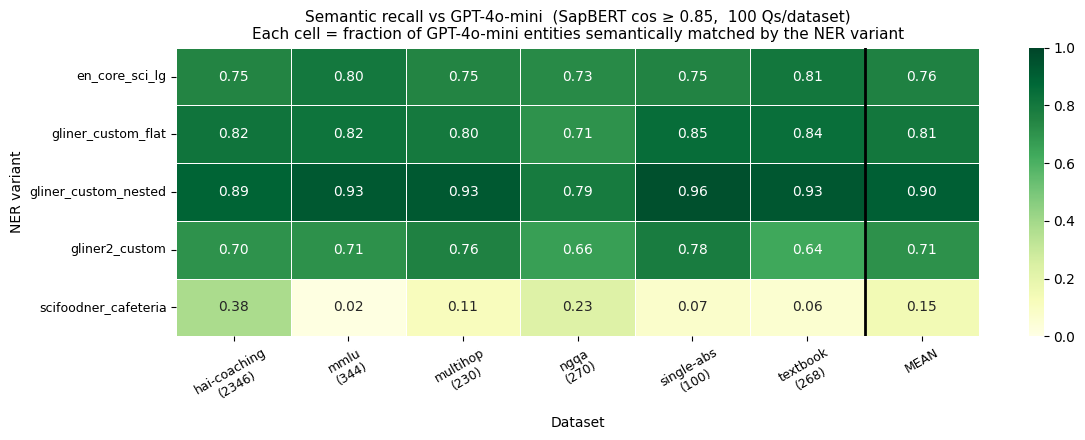

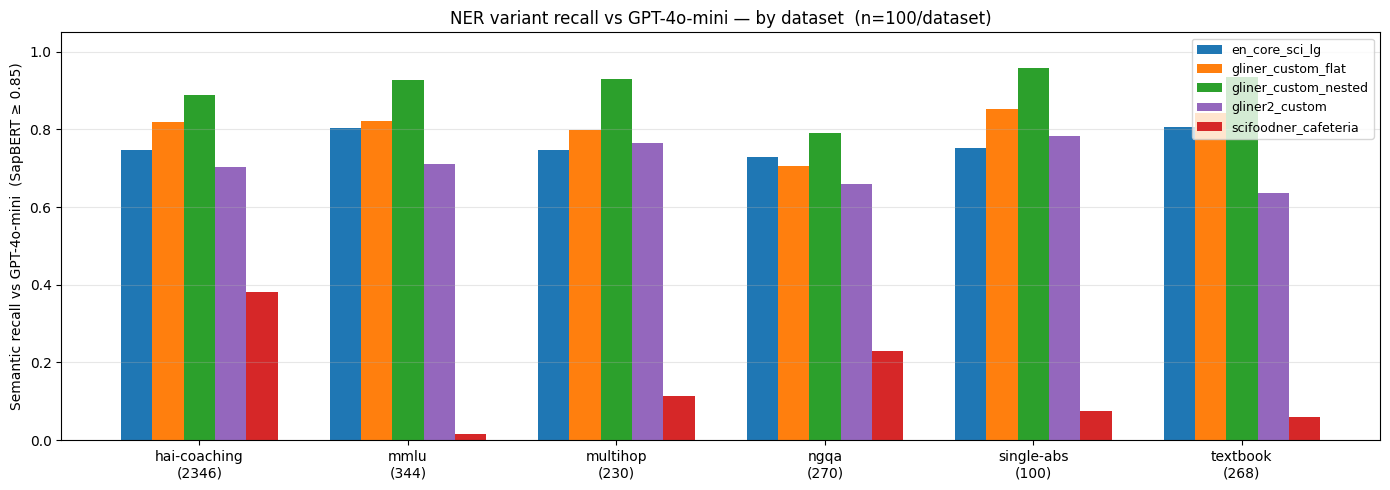


Outputs saved → /mnt/data/makis/wisefood/experiments/tests/ner_results/cross_dataset/gpt_comparison_n100

=== Full recall table (with MEAN column) ===


,hai-coaching\n(2346),mmlu\n(344),multihop\n(230),ngqa\n(270),single-abs\n(100),textbook\n(268),MEAN
model,,,,,,,
en_core_sci_lg,0.747,0.803,0.748,0.730,0.751,0.808,0.764
gliner_custom_flat,0.819,0.821,0.798,0.706,0.851,0.843,0.806
gliner_custom_nested,0.888,0.926,0.929,0.792,0.959,0.934,0.905
gliner2_custom,0.703,0.710,0.764,0.661,0.782,0.636,0.709
scifoodner_cafeteria,0.383,0.015,0.114,0.230,0.074,0.059,0.146


In [20]:
# ── Cell 19: Heatmap + bar chart — semantic recall vs GPT-4o-mini ─────────────
GPT_OUT = OUT_BASE / f"gpt_comparison_n{SAMPLE_PER_DATASET}"
GPT_OUT.mkdir(exist_ok=True)

coverage_df.to_csv(GPT_OUT / "coverage_vs_gpt.csv", index=False)
cov_pivot.to_csv(GPT_OUT / "coverage_pivot_vs_gpt.csv")

# ── Build plot frame: rename dataset columns + add MEAN "heat column" ─────────
cov_plot = cov_pivot.copy()
cov_plot.columns = [DATASET_LABELS.get(c, c) for c in cov_plot.columns]
cov_plot["MEAN"] = cov_plot.mean(axis=1)

# ── 1. Heatmap — rows = NER variants, cols = datasets + MEAN ─────────────────
fig, ax = plt.subplots(figsize=(12, 4.5))
sns.heatmap(
    cov_plot, annot=True, fmt=".2f", cmap="YlGn",
    linewidths=0.5, ax=ax, vmin=0, vmax=1,
    annot_kws={"size": 10}, linecolor="white",
)
ax.axvline(x=cov_plot.shape[1] - 1, color="black", lw=2)
ax.set_title(
    f"Semantic recall vs GPT-4o-mini  (SapBERT cos ≥ {SEM_THRESHOLD},  "
    f"{SAMPLE_PER_DATASET} Qs/dataset)\n"
    "Each cell = fraction of GPT-4o-mini entities semantically matched by the NER variant",
    fontsize=11,
)
ax.set_xlabel("Dataset")
ax.set_ylabel("NER variant")
ax.tick_params(axis="x", rotation=30, labelsize=9)
ax.tick_params(axis="y", rotation=0,  labelsize=9)
fig.tight_layout()
fig.savefig(GPT_OUT / "semantic_recall_vs_gpt_heatmap.png", dpi=200, bbox_inches="tight")
plt.show(); plt.close()

# ── 2. Grouped bar chart ──────────────────────────────────────────────────────
ds_cols = list(cov_pivot.columns)
x, width = np.arange(len(ds_cols)), 0.15
fig, ax = plt.subplots(figsize=(14, 5))
for i, model in enumerate(ALL_MODELS):
    vals = [cov_pivot.loc[model, ds] if model in cov_pivot.index else np.nan for ds in ds_cols]
    ax.bar(x + i * width, vals, width, label=model, color=MODEL_COLORS[model])
ax.set_xticks(x + width * 2)
ax.set_xticklabels([DATASET_LABELS.get(d, d) for d in ds_cols], fontsize=10)
ax.set_ylabel(f"Semantic recall vs GPT-4o-mini  (SapBERT ≥ {SEM_THRESHOLD})")
ax.set_title(f"NER variant recall vs GPT-4o-mini — by dataset  (n={SAMPLE_PER_DATASET}/dataset)")
ax.set_ylim(0, 1.05); ax.legend(fontsize=9, loc="upper right"); ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(GPT_OUT / "semantic_recall_vs_gpt_bar.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"\nOutputs saved → {GPT_OUT}")
print("\n=== Full recall table (with MEAN column) ===")
display(cov_plot.round(3))

In [21]:
# ── Cell 20: Qualitative comparison — NER variants vs GPT-4o-mini ─────────────
#
# Prints the N_QUAL questions with the most GPT entities (richest signal)
# and shows what each NER variant found alongside the GPT reference.

N_QUAL = 15
SEP    = "─" * 108

q_text_map = all_sampled.set_index("question_id")["question"].to_dict()
q_ds_map   = all_sampled.set_index("question_id")["dataset"].to_dict()

# Sort by GPT entity richness so the most informative questions come first
gpt_counts = {
    info["question_id"]: len(info["entities"])
    for info in gpt_entities.values()
}
qual_qids = sorted(gpt_counts, key=lambda q: -gpt_counts[q])[:N_QUAL]

qual_lines = []
for qid in qual_qids:
    ds    = q_ds_map.get(qid, "?")
    gpt_e = gpt_ents_by_qid.get(qid, [])
    qual_lines.append(SEP)
    qual_lines.append(f"Q{qid:4d} [{ds}]:  {q_text_map.get(qid, '')}")
    qual_lines.append(f"  [gpt-4o-mini   ] ({len(gpt_e):2d})  {gpt_e}")
    for model in ALL_MODELS:
        try:
            ents = list(ner_ent_idx.loc[(qid, model)])
        except KeyError:
            ents = []
        tag = MODEL_TAGS.get(model, model)
        qual_lines.append(f"  [{tag:14s}] ({len(ents):2d})  {ents}")
qual_lines.append(SEP)

qual_text = "\n".join(qual_lines)
print(qual_text)

out_path = GPT_OUT / "qualitative_vs_gpt.txt"
out_path.write_text(qual_text, encoding="utf-8")
print(f"\nQualitative comparison saved → {out_path}")

────────────────────────────────────────────────────────────────────────────────────────────────────────────
Q 504 [ngqa]:  A person has the following dietary and health profile:
- Eats lots of shellfish;
- Eats lots of fish;
- Adds little to no salt at table;
- Heavy cigarette smoker;
- Drinks Alcohol more than average;
- Eats lots of frozen food;
- Eats many ready to eat meals;
- Takes more supplements;
- Uses little to no salt in preparation;
- Drinks lots of water;
- Claims to have a good diet;
- Ate more food than usual;
- Ate less food than usual;
- Eats low salt diet;
- Eats gluten free diet;
- Has Weight loss/Low calorie diet;
- Has Sugar free/Low sugar diet;
- Has High protein diet.

"Jambalaya with meat and rice" is a food that belongs to the category of Rice mixed dishes. It contains the following ingredients: 
1) Spices, pepper, black;
2) Chicken, NS as to part, rotisserie, skin not eaten;
3) Vegetable oil, NFS;
4) Chorizo, pork and beef;
5) Chorizo;
6) Rice, white, long-gr

---
### SciFoodNER-focused qualitative — failure cases vs GLiNER2

Shows questions where GPT-4o-mini found ≥5 entities but SciFoodNER found <2. These are the cases that would cause entity-aware retrieval to silently degrade to simple retrieval.


In [22]:
# ── SciFoodNER-focused qualitative ───────────────────────────────────────────
# Questions where GPT found rich entity signal but SciFoodNER was nearly silent.
# These are the critical failure cases for graph-guided retrieval.

SCIFOODNER_FOCUS = ["scifoodner_cafeteria", "gliner_custom_flat",
                    "gliner2_custom", "en_core_sci_lg"]
N_SFNER = 20

# Build scifoodner entity counts for sampled questions
sfner_counts = {}
for qid in gpt_counts:
    try:
        sfner_counts[qid] = len(list(ner_ent_idx.loc[(qid, "scifoodner_cafeteria")]))
    except KeyError:
        sfner_counts[qid] = 0

# Failure cases: GPT rich (≥5), SciFoodNER near-silent (<2)
failure_qids = sorted(
    [qid for qid in gpt_counts if gpt_counts[qid] >= 5 and sfner_counts.get(qid, 0) < 2],
    key=lambda q: -gpt_counts[q]
)[:N_SFNER]

sfner_lines = []
for qid in failure_qids:
    ds    = q_ds_map.get(qid, "?")
    gpt_e = gpt_ents_by_qid.get(qid, [])
    sfner_lines.append(SEP)
    sfner_lines.append(f"Q{qid:4d} [{ds}]:  {q_text_map.get(qid, '')[:200]}")
    sfner_lines.append(f"  [gpt-4o-mini   ] ({len(gpt_e):2d})  {gpt_e}")
    for model in SCIFOODNER_FOCUS:
        try:
            ents = list(ner_ent_idx.loc[(qid, model)])
        except KeyError:
            ents = []
        tag = MODEL_TAGS.get(model, model)
        sfner_lines.append(f"  [{tag:14s}] ({len(ents):2d})  {ents}")
sfner_lines.append(SEP)
sfner_text = "\n".join(sfner_lines)
print(sfner_text)
(GPT_OUT / "qualitative_scifoodner_focus.txt").write_text(sfner_text, encoding="utf-8")
print(f"\nSciFoodNER failure cases saved → {GPT_OUT / 'qualitative_scifoodner_focus.txt'}")
print(f"Failure cases shown: {len(failure_qids)} / {len(gpt_counts)} sampled questions")


────────────────────────────────────────────────────────────────────────────────────────────────────────────
Q  20 [multihop_qa]:  Considering that nickel antagonizes the absorption of iron, copper, and zinc, but can also substitute for magnesium in the complement system’s C3 convertase enzyme to enhance its stability and activit
  [gpt-4o-mini   ] ( 9)  ['nickel', 'iron', 'copper', 'zinc', 'magnesium', 'complement system', 'c3 convertase enzyme', 'mineral nutrition', 'immune function']
  [scifoodner    ] ( 0)  []
  [gliner_flat   ] ( 9)  ['nickel', 'iron', 'copper', 'zinc', 'magnesium', 'complement system', 'c3 convertase enzyme', 'mineral nutrition', 'immune function']
  [gliner2       ] ( 8)  ['nickel', 'iron', 'copper', 'zinc', 'magnesium', 'c3 convertase enzyme', 'mineral nutrition', 'immune function']
  [sci_lg        ] (12)  ['nickel', 'antagonizes', 'absorption', 'iron', 'copper', 'zinc', 'magnesium', 'complement system’s c3 convertase enzyme', 'stability', 'activity', 'mineral

In [23]:
# ── Cell 21: Semantic precision + per-question F1 vs GPT-4o-mini ─────────────
#
# Adds the missing direction to Cell 18's recall-only view:
#
#   precision(NER, GPT) = |{n ∈ NER : ∃g ∈ GPT, cos(n,g) ≥ τ}| / |NER|
#   "what fraction of what NER found is validated by GPT?"
#
# F1 is then computed PER QUESTION and averaged (not from averaged P & R),
# so it correctly penalises variance across questions.
#
# NaN conventions (consistent with Cell 18):
#   • recall  NaN  when GPT found nothing      (no reference → skip question)
#   • precision NaN when NER found nothing     (undefined    → skip question)
#   • f1      NaN  when either P or R is NaN   (skip question for F1 average)
#
# A model that overproduces entities (e.g. gliner_nested with 21 spans for a
# question where GPT listed 15) will have high recall but lower precision,
# because many extra nested spans (e.g. "cardiovascular disease rates" vs
# "cardiovascular disease") may not match any GPT entity.

def semantic_precision_vs_gpt(ner_ents, gpt_ents, emb_cache, threshold=SEM_THRESHOLD):
    """
    Fraction of NER entities semantically covered by some GPT entity.
    Returns NaN when NER found nothing (precision undefined; skip question).
    """
    n_keys = [e for e in ner_ents if e in emb_cache]
    if not n_keys:
        return np.nan          # NER produced nothing; skip
    g_keys = [e for e in gpt_ents if e in emb_cache]
    if not g_keys:
        return 0.0             # NER found things but GPT validates none
    N    = torch.stack([emb_cache[e] for e in n_keys])   # (|N|, H)
    G    = torch.stack([emb_cache[e] for e in g_keys])   # (|G|, H)
    best = (N @ G.T).max(dim=1).values                   # best GPT match per NER entity
    return (best >= threshold).float().mean().item()


def _nanmean(vals):
    v = [x for x in vals if not np.isnan(x)]
    return round(np.mean(v), 4) if v else np.nan


prf_records = []
for ds_name in SAMPLE_DATASETS:
    qids_ds = sampled_frames[ds_name]["question_id"].tolist()
    for model in ALL_MODELS:
        rec_scores, prec_scores, f1_scores = [], [], []
        cnt_per_q = []

        for qid in qids_ds:
            gpt_e = gpt_ents_by_qid.get(qid, [])
            try:
                ner_e = [e.lower() for e in ner_ent_idx.loc[(qid, model)]
                         if isinstance(e, str)]
            except KeyError:
                ner_e = []

            rec  = semantic_recall_vs_gpt(ner_e, gpt_e, emb_cache_gpt)
            prec = semantic_precision_vs_gpt(ner_e, gpt_e, emb_cache_gpt)

            # per-question F1 — skip if either metric is undefined for this Q
            if not np.isnan(rec) and not np.isnan(prec):
                f1 = (2 * prec * rec / (prec + rec)) if (prec + rec) > 0 else 0.0
            else:
                f1 = np.nan

            rec_scores.append(rec)
            prec_scores.append(prec)
            f1_scores.append(f1)
            cnt_per_q.append(len(ner_e))

        prf_records.append({
            "model":            model,
            "dataset":          ds_name,
            "recall":           _nanmean(rec_scores),
            "precision":        _nanmean(prec_scores),
            "f1":               _nanmean(f1_scores),
            "avg_entities":     round(np.mean(cnt_per_q), 2),
            "n_recall_valid":   sum(1 for x in rec_scores  if not np.isnan(x)),
            "n_prec_valid":     sum(1 for x in prec_scores if not np.isnan(x)),
            "n_f1_valid":       sum(1 for x in f1_scores   if not np.isnan(x)),
        })

prf_df = pd.DataFrame(prf_records)

recall_pivot    = prf_df.pivot(index="model", columns="dataset", values="recall").reindex(ALL_MODELS)
precision_pivot = prf_df.pivot(index="model", columns="dataset", values="precision").reindex(ALL_MODELS)
f1_pivot        = prf_df.pivot(index="model", columns="dataset", values="f1").reindex(ALL_MODELS)

print(f"=== Semantic RECALL vs GPT-4o-mini  (SapBERT ≥ {SEM_THRESHOLD}) ===")
display(recall_pivot.round(3))
print(f"\n=== Semantic PRECISION vs GPT-4o-mini ===")
display(precision_pivot.round(3))
print(f"\n=== Semantic F1 vs GPT-4o-mini  (per-question F1, then averaged) ===")
display(f1_pivot.round(3))

=== Semantic RECALL vs GPT-4o-mini  (SapBERT ≥ 0.85) ===


dataset,hai_coaching,mmlu,multihop_qa,ngqa,single_abstract,textbook_lyssari
model,,,,,,
en_core_sci_lg,0.747,0.803,0.748,0.730,0.751,0.808
gliner_custom_flat,0.819,0.821,0.798,0.706,0.851,0.843
gliner_custom_nested,0.888,0.926,0.929,0.792,0.959,0.934
gliner2_custom,0.703,0.710,0.764,0.661,0.782,0.636
scifoodner_cafeteria,0.383,0.015,0.114,0.230,0.074,0.059



=== Semantic PRECISION vs GPT-4o-mini ===


dataset,hai_coaching,mmlu,multihop_qa,ngqa,single_abstract,textbook_lyssari
model,,,,,,
en_core_sci_lg,0.275,0.276,0.390,0.279,0.334,0.361
gliner_custom_flat,0.289,0.282,0.570,0.633,0.468,0.369
gliner_custom_nested,0.275,0.249,0.516,0.613,0.387,0.342
gliner2_custom,0.554,0.500,0.736,0.640,0.593,0.638
scifoodner_cafeteria,0.706,0.667,0.793,0.823,0.800,0.727



=== Semantic F1 vs GPT-4o-mini  (per-question F1, then averaged) ===


dataset,hai_coaching,mmlu,multihop_qa,ngqa,single_abstract,textbook_lyssari
model,,,,,,
en_core_sci_lg,0.482,0.606,0.509,0.402,0.548,0.605
gliner_custom_flat,0.515,0.613,0.658,0.664,0.707,0.622
gliner_custom_nested,0.510,0.586,0.654,0.686,0.656,0.617
gliner2_custom,0.696,0.763,0.739,0.647,0.773,0.756
scifoodner_cafeteria,0.664,0.583,0.402,0.353,0.475,0.589


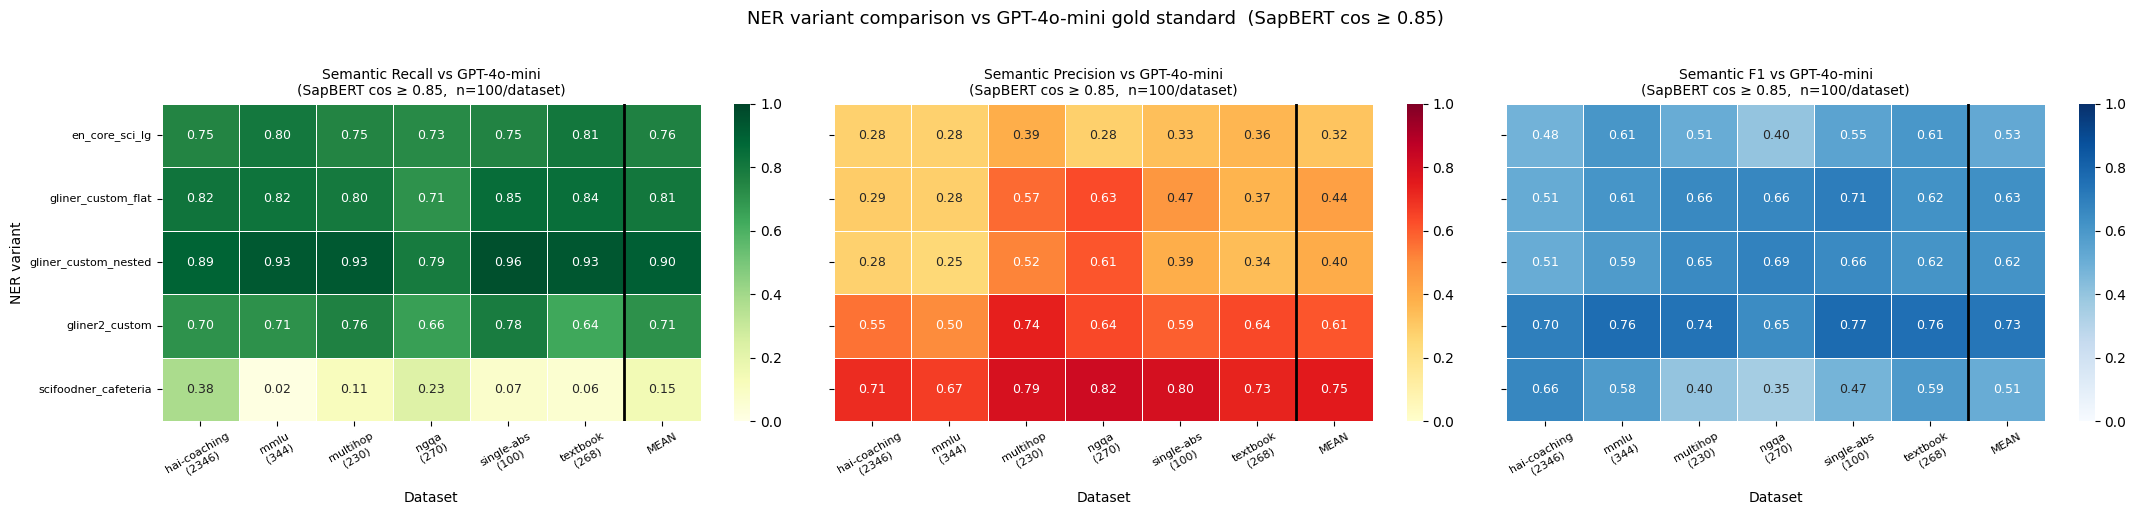


=== Summary: cross-dataset means, sorted by F1 ===


,Recall (mean),Precision (mean),F1 (mean),Avg entities/Q
model,,,,
gliner2_custom,0.709,0.610,0.729,6.06
gliner_custom_flat,0.806,0.435,0.630,8.45
gliner_custom_nested,0.905,0.397,0.618,10.97
en_core_sci_lg,0.764,0.319,0.526,14.68
scifoodner_cafeteria,0.146,0.753,0.511,1.39



All outputs saved → /mnt/data/makis/wisefood/experiments/tests/ner_results/cross_dataset/gpt_comparison_n100


In [24]:
# ── Cell 22: 3-panel heatmap (Recall | Precision | F1) + summary table ────────

def _add_mean_col(pivot):
    p = pivot.copy()
    p.columns = [DATASET_LABELS.get(c, c) for c in p.columns]
    p["MEAN"] = p.mean(axis=1)
    return p

rec_plot  = _add_mean_col(recall_pivot)
prec_plot = _add_mean_col(precision_pivot)
f1_plot   = _add_mean_col(f1_pivot)

# ── 3-panel heatmap ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 5), sharey=True)
panels = [
    (rec_plot,  "Recall",    "YlGn"),
    (prec_plot, "Precision", "YlOrRd"),
    (f1_plot,   "F1",        "Blues"),
]
for ax, (data, metric, cmap) in zip(axes, panels):
    sns.heatmap(
        data, annot=True, fmt=".2f", cmap=cmap,
        linewidths=0.5, ax=ax, vmin=0, vmax=1,
        annot_kws={"size": 9}, linecolor="white",
    )
    ax.axvline(x=data.shape[1] - 1, color="black", lw=2)   # bold MEAN separator
    ax.set_title(
        f"Semantic {metric} vs GPT-4o-mini\n"
        f"(SapBERT cos ≥ {SEM_THRESHOLD},  n={SAMPLE_PER_DATASET}/dataset)",
        fontsize=10,
    )
    ax.set_xlabel("Dataset")
    ax.set_ylabel("NER variant" if ax is axes[0] else "")
    ax.tick_params(axis="x", rotation=30, labelsize=8)
    ax.tick_params(axis="y", rotation=0,  labelsize=8)

fig.suptitle(
    "NER variant comparison vs GPT-4o-mini gold standard  "
    f"(SapBERT cos ≥ {SEM_THRESHOLD})",
    fontsize=13, y=1.02,
)
fig.tight_layout()
fig.savefig(GPT_OUT / "recall_precision_f1_heatmap.png", dpi=200, bbox_inches="tight")
plt.show(); plt.close()

# ── Summary table — sorted by F1 ─────────────────────────────────────────────
avg_ent = prf_df.groupby("model")["avg_entities"].mean().round(2)
summary = pd.DataFrame({
    "Recall (mean)":    recall_pivot.mean(axis=1).round(3),
    "Precision (mean)": precision_pivot.mean(axis=1).round(3),
    "F1 (mean)":        f1_pivot.mean(axis=1).round(3),
    "Avg entities/Q":   avg_ent,
}).reindex(ALL_MODELS).sort_values("F1 (mean)", ascending=False)

print("\n=== Summary: cross-dataset means, sorted by F1 ===")
display(summary)

prf_df.to_csv(GPT_OUT / "prf_by_dataset.csv",   index=False)
summary.to_csv(GPT_OUT / "prf_summary.csv")
f1_plot.round(3).to_csv(GPT_OUT / "f1_pivot.csv")
precision_pivot.round(3).to_csv(GPT_OUT / "precision_pivot.csv")
print(f"\nAll outputs saved → {GPT_OUT}")